In [3]:
%matplotlib widget

import struct
import cdflib
import numpy as np
import datetime as dt
import spiceypy as spice
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.fft import fft, fftfreq
from scipy.signal import butter, filtfilt
from utilities import print_info, print_entire

def filter_out_start_config_noise(data, epoch, removal_width = 32, new_config_delay = 0.1):
    # Create a mask for the data
    noise_mask = np.zeros(len(data))

    # Mask the next samples when dt is above new_config_delay, for which a new config. has been made
    delta_t = np.diff(epoch)
    delta_t = [dt.total_seconds() for dt in delta_t]

    i = 0
    for dt in delta_t:
        if dt > new_config_delay:
            noise_mask[i:i+removal_width] = 1
        i +=1

    noise_mask[:removal_width] = 1

    data[noise_mask == 1] = np.nan

    return data

def multiply_lists_by_33matrix(list1, list2, list3, matrix):
    res1 = np.zeros(len(list1))
    res2 = np.zeros(len(list1))
    res3 = np.zeros(len(list1))
    for i in range(len(list1)):
        vector = np.array([list1[i], list2[i], list3[i]])
        res1[i] = vector[0]*matrix[0, 0] + vector[1]*matrix[0, 1] + vector[2]*matrix[0, 2]
        res2[i] = vector[0]*matrix[1, 0] + vector[1]*matrix[1, 1] + vector[2]*matrix[1, 2]
        res3[i] = vector[0]*matrix[2, 0] + vector[1]*matrix[2, 1] + vector[2]*matrix[2, 2]
    return res1, res2, res3

def multiply_lists_by_44matrix(list1, list2, list3, list4, matrix):
    res1 = np.zeros(len(list1))
    res2 = np.zeros(len(list1))
    res3 = np.zeros(len(list1))
    res4 = np.zeros(len(list1))
    for i in range(len(list1)):
        vector = np.array([list1[i], list2[i], list3[i], list4[i]])
        res1[i] = vector[0]*matrix[0, 0] + vector[1]*matrix[0, 1] + vector[2]*matrix[0, 2] + vector[3]*matrix[0, 3]
        res2[i] = vector[0]*matrix[1, 0] + vector[1]*matrix[1, 1] + vector[2]*matrix[1, 2] + vector[3]*matrix[1, 3]
        res3[i] = vector[0]*matrix[2, 0] + vector[1]*matrix[2, 1] + vector[2]*matrix[2, 2] + vector[3]*matrix[2, 3]
        res4[i] = vector[0]*matrix[3, 0] + vector[1]*matrix[3, 1] + vector[2]*matrix[3, 2] + vector[3]*matrix[3, 3]
    return res1, res2, res3, res4

def butter_highpass(cutoff, fs, order=5):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='highpass', analog=False)
    return b, a

def highpass_filter(data, cutoff, fs, order=5):
    b, a = butter_highpass(cutoff, fs, order=order)
    valid_indices = ~np.isnan(data)
    y = filtfilt(b, a, data[valid_indices])
    return y

def convert_binstr_to_double_precision(bin_str_array):
    doubles = []
    for bin_str in bin_str_array:
        # Convert binary string to 8-byte integer
        try :
            int_val = int(bin_str, 2)
            bytes_val = int_val.to_bytes(8, byteorder='big')
            double_val = struct.unpack('>d', bytes_val)[0]
            doubles.append(double_val)
        except ValueError as e:
            doubles.append(np.nan)
    return np.array(doubles)

def extract_double_from_columns(data, col_start, col_end):
    # Slice relevant columns: shape (len_JMAG, 8)
    bytes_slice = data[:, col_start:col_end]
    # Transpose and flatten to match MATLAB logic
    bin_strs = [''.join(f'{byte:08b}' for byte in row) for row in bytes_slice]
    return convert_binstr_to_double_precision(bin_strs)

# Magnetopause (Shue et al. 1997)
def magnetopause(P_sw, theta):
    R0 = 10.22 * (P_sw / 1.0)**(-1/6)  # subsolar point in Earth radii
    alpha = 0.5  # typical value
    r = R0 * (2 / (1 + np.cos(theta)))**alpha
    return r

# Bow Shock (Farris & Russell 1994)
def bow_shock(P_sw, theta):
    R0 = 14.5 * (P_sw / 1.0)**(-1/6)  # subsolar point in Earth radii
    epsilon = 0.8  # shape parameter
    r = (R0 * (1 + epsilon)) / (1 + epsilon * np.cos(theta))
    return r

# Rotation matrix to go from JMAG OBS frame to JUICE frame
R_JMAG = np.array([
    [-7.77145961*1e-1,  8.39299198*1e-17,   -6.29320391*1e-1],
    [-9.51729314*1e-17, -1.00000000*1e0,    -1.58371803*1e-17],
    [-6.29320391*1e-1,  4.75864657*1e-17,   7.77145961*1e-1]])

diff2volt = np.array([
    [-1.0, -1.0, -1.0, 1.0],
    [0.0, -1.0, -1.0, 1.0],
    [0.0, 0.0, -1.0, 1.0],
    [0.0, 0.0, 0.0, 1.0]])

volt2diff = np.array([
    [-1.0, 1.0, 0.0, 0.0],
    [0.0, -1.0, 1.0, 0.0],
    [0.0, 0.0, -1.0, 1.0],
    [0.0, 0.0, 0.0, 1.0]])

volt2E = np.array([
    [0.1852, 0.1923, 0.1917],
    [0.1320, -0.0112, -0.0322],
    [0.0, 0.1398, 0.0]])

E2volt = np.linalg.inv(volt2E)

probe_dist = 1e-3*np.array([6287.3, 7152.0, 9611.4]) # in m, LP1-LP2, LP2-LP3, LP3-LP4

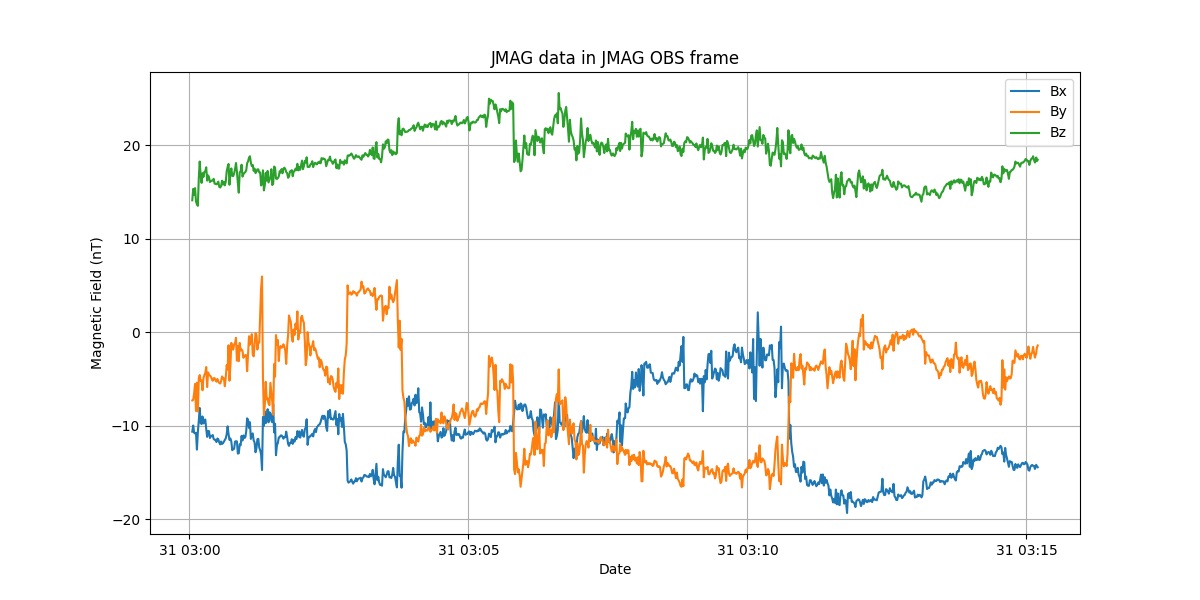

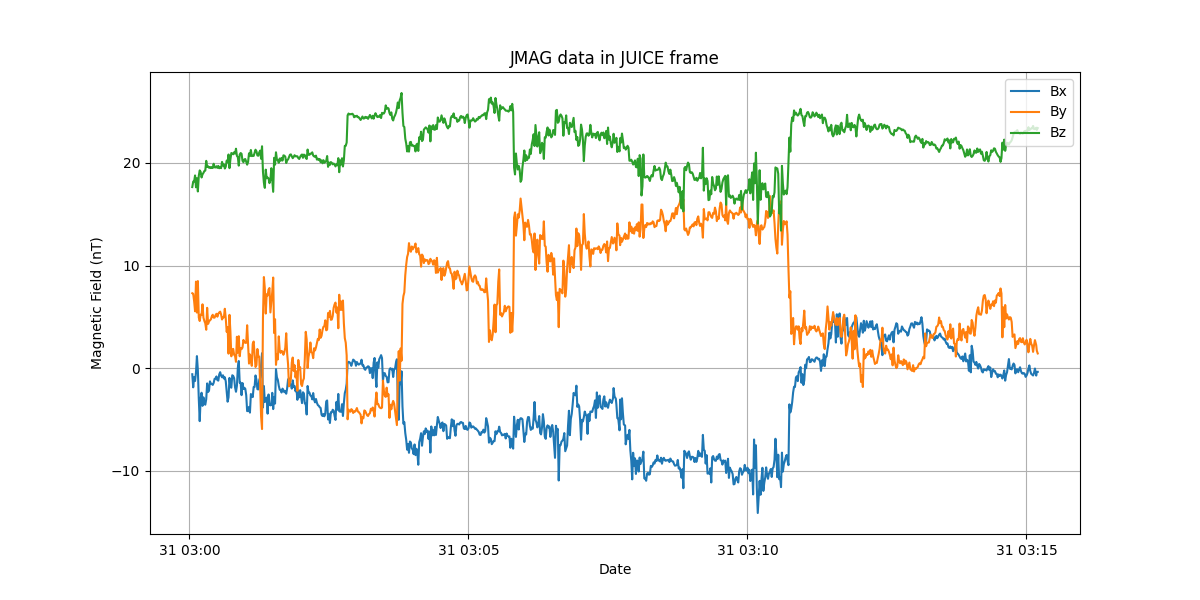

In [12]:
# Get and rotate JMAG data for 31/03/2025

jmag_cdf = cdflib.CDF('../DATA/jmag_echoed/2025/03/31/JUICE_LU_RPWI-PPTD-LWYRPW79710_20250331T030003_V01.cdf')

jmag_epoch = jmag_cdf.varget('Epoch')
jmag_epoch = cdflib.cdfepoch.to_datetime(jmag_epoch)
jmag_epoch = np.array(jmag_epoch, dtype='datetime64[ms]').astype('O')
Bx = jmag_cdf.varget('LWT79713')
By = jmag_cdf.varget('LWT79714')
Bz = jmag_cdf.varget('LWT79715')

plt.figure(figsize=(12, 6))
plt.plot(jmag_epoch, Bx, label='Bx')
plt.plot(jmag_epoch, By, label='By')
plt.plot(jmag_epoch, Bz, label='Bz')
plt.title('JMAG data in JMAG OBS frame')
plt.legend(loc = 'upper right')
plt.xlabel('Date')
plt.ylabel('Magnetic Field (nT)')
plt.grid()
plt.show()

# Rotate the magnetic field vectors to the JUICE frame
Bx_rot = R_JMAG[0,0]*Bx + R_JMAG[0,1]*By + R_JMAG[0,2]*Bz
By_rot = R_JMAG[1,0]*Bx + R_JMAG[1,1]*By + R_JMAG[1,2]*Bz
Bz_rot = R_JMAG[2,0]*Bx + R_JMAG[2,1]*By + R_JMAG[2,2]*Bz
Bx = Bx_rot
By = By_rot
Bz = Bz_rot

plt.figure(figsize=(12, 6))
plt.plot(jmag_epoch, Bx, label='Bx')
plt.plot(jmag_epoch, By, label='By')
plt.plot(jmag_epoch, Bz, label='Bz')
plt.title('JMAG data in JUICE frame')
plt.legend(loc = 'upper right')
plt.xlabel('Date')
plt.ylabel('Magnetic Field (nT)')
plt.grid()
plt.show()

Distance from JUICE to Sun: 139886025.9621548 km
Distance from WIND to Sun: 148037524.90938532 km
Delta time: 7.110398057099633 hours


C:\Users\lesco\AppData\Local\Temp\ipykernel_1584\349211493.py:41: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(12, 6))


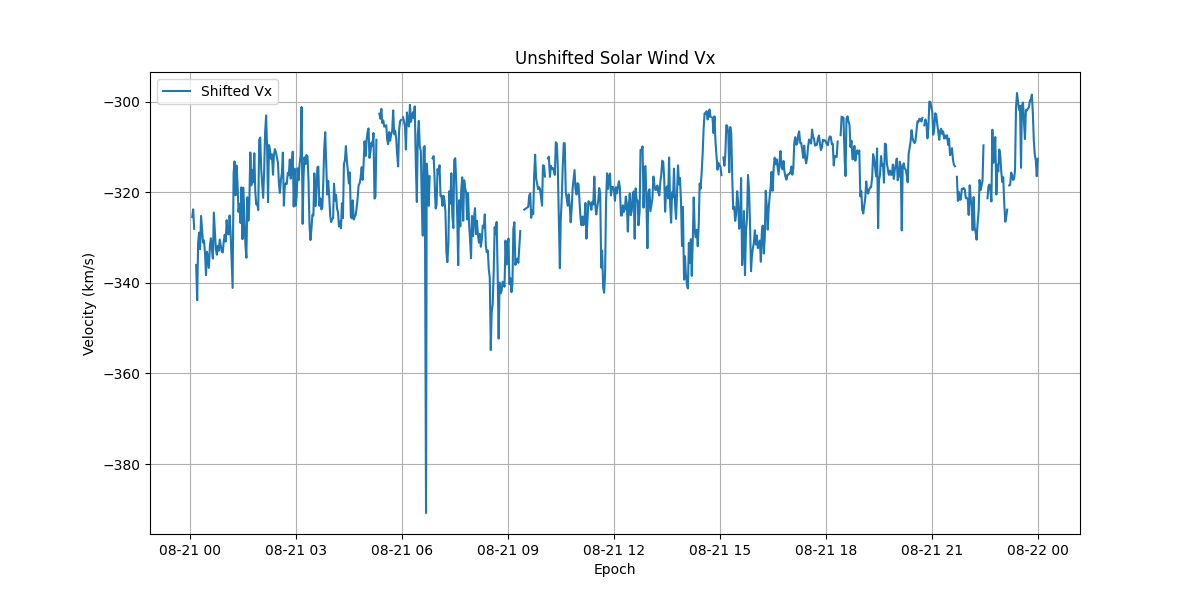

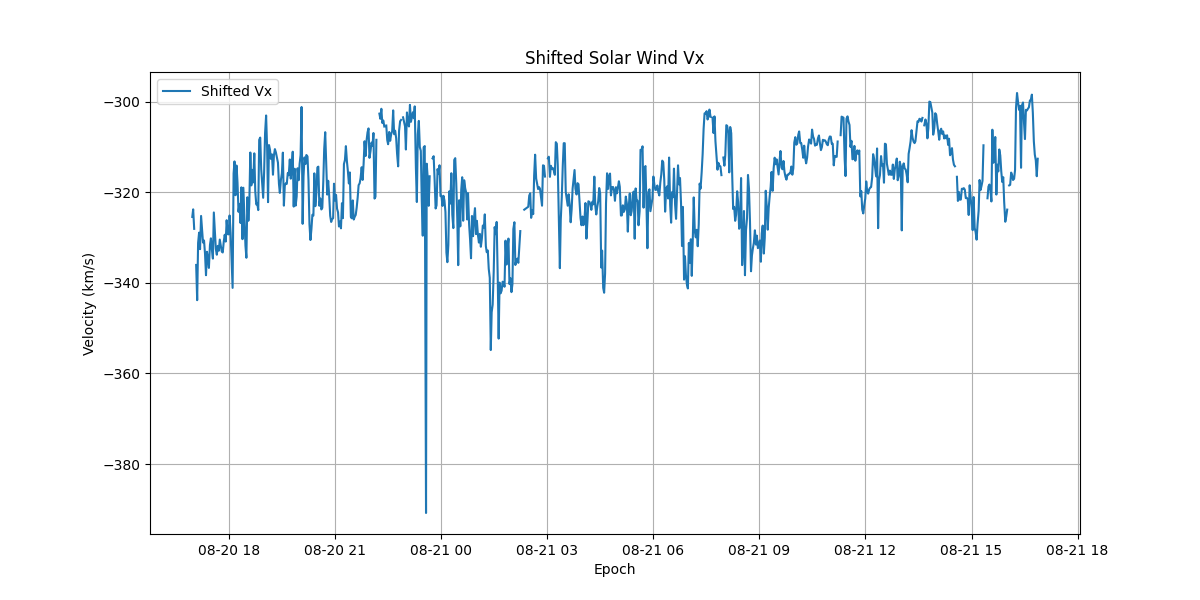

In [13]:
# Get and shift SW data for 31/03/2025

wind_cdf = cdflib.CDF("../DATA/wi_k0s_swe_20240821000335_20240821235902_cdaweb.cdf")

V_GSE = wind_cdf.varget('V_GSE')
WIND_pos_gse = wind_cdf.varget('SC_pos_gse')
wind_epoch = wind_cdf.varget('Epoch')
wind_epoch = cdflib.cdfepoch.to_datetime(wind_epoch)
wind_epoch = np.array(wind_epoch, dtype='datetime64[ms]').astype('O')

V_GSE[V_GSE < -1e5] = np.nan # Remove all of the 0 values from the solar wind data
sw_speed = -np.nanmean(V_GSE[:, 0], axis=0) # Get the average speed of the solar wind in km/s during the considered time period

# Load the necessary SPICE kernels
spice.furnsh("../SPICE/JUICE/kernels/mk/juice_ops.tm")

et = spice.str2et("2025-03-31T00:00:00")

pos_earth_j2000, _ = spice.spkpos("EARTH", et, "J2000", "NONE", "SUN")
distance_earth_sun = np.linalg.norm(pos_earth_j2000)

# Getting WIND's distance to the Sun : in GSE, X axis is Sun-Earth direction, 
# so just need to change the X coordinate to recenter the coordinate system on the Sun
WIND_pos_sun_centered_x = WIND_pos_gse[:, 0] - distance_earth_sun

WIND_distance_sun = np.sqrt(WIND_pos_sun_centered_x**2 + WIND_pos_gse[:, 1]**2 + WIND_pos_gse[:, 2]**2)
avrg_WIND_distance_sun = np.nanmean(WIND_distance_sun)

pos_juice_j2000, _ = spice.spkpos("JUICE", et, "J2000", "NONE", "SUN")
distance_juice_sun = np.linalg.norm(pos_juice_j2000)

print(f"Distance from JUICE to Sun: {distance_juice_sun} km")
print(f"Distance from WIND to Sun: {avrg_WIND_distance_sun} km")

delta_distance = avrg_WIND_distance_sun - distance_juice_sun

delta_time = delta_distance / sw_speed
print(f"Delta time: {delta_time/(60*60)} hours")

# Plot before shifting
plt.figure(figsize=(12, 6))
plt.plot(wind_epoch, V_GSE[:, 0], label='Shifted Vx')
plt.title('Unshifted Solar Wind Vx')
plt.xlabel('Epoch')
plt.ylabel('Velocity (km/s)')
plt.legend()
plt.grid()
plt.show()

# Shift the solar wind data to delta_time seconds earlier this way the solar wind data is plotted on the time it reaches JUICE
wind_epoch_shifted = wind_epoch - dt.timedelta(seconds=delta_time)
plt.figure(figsize=(12, 6))
plt.plot(wind_epoch_shifted, V_GSE[:, 0], label='Shifted Vx')
plt.title('Shifted Solar Wind Vx')
plt.xlabel('Epoch')
plt.ylabel('Velocity (km/s)')
plt.legend()
plt.grid()
plt.show()

spice.unload("SPICE/JUICE/kernels/mk/juice_ops.tm")

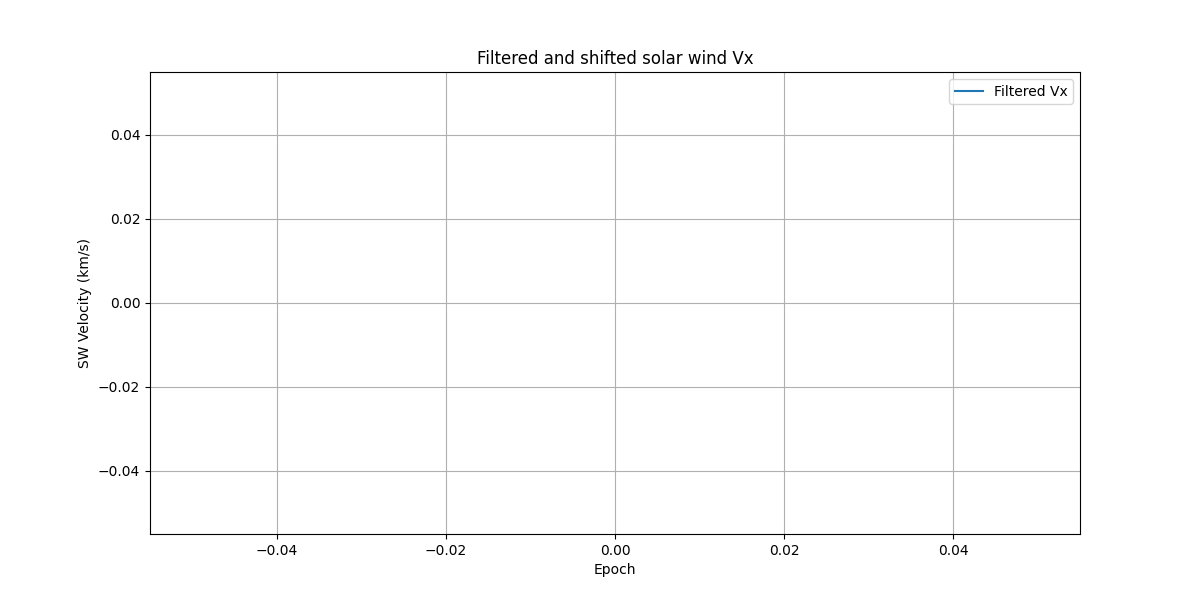

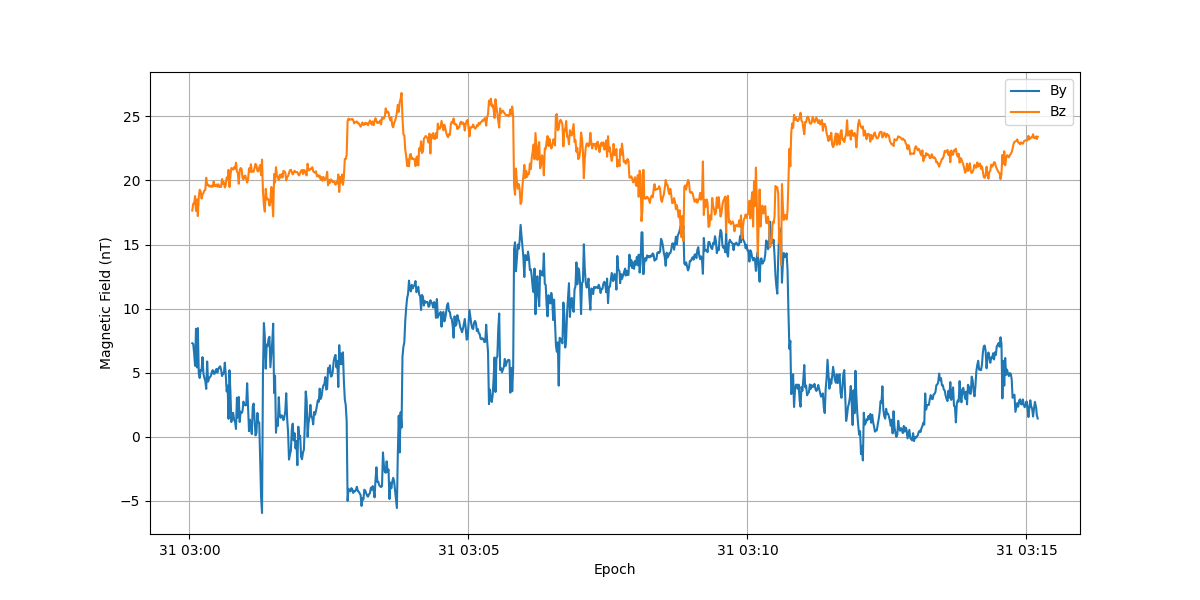

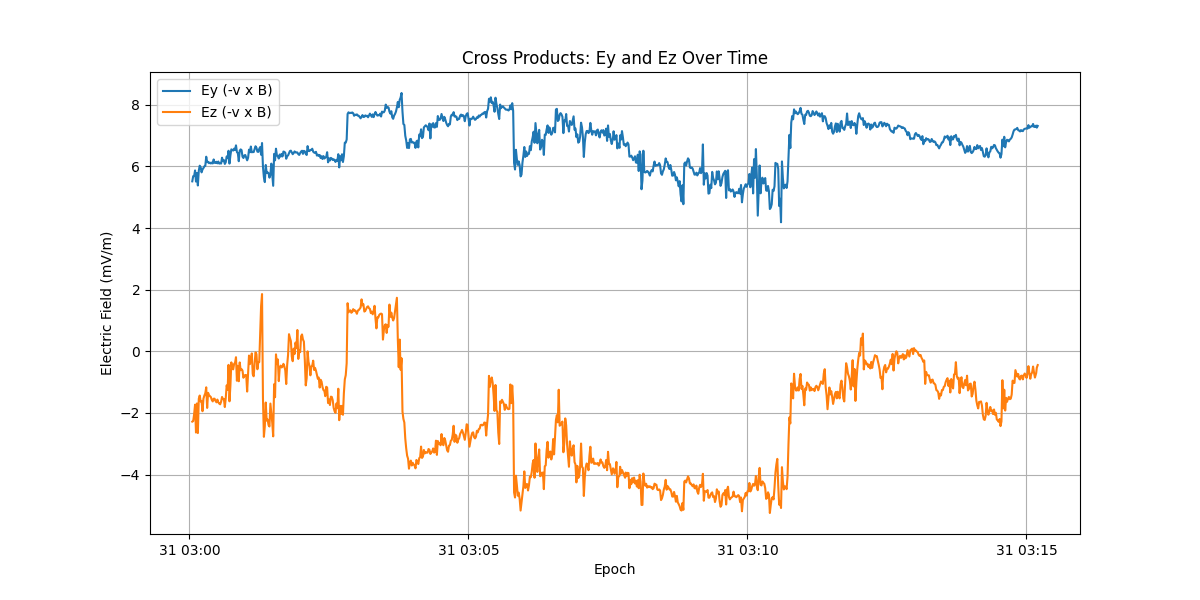

In [14]:
# Calculate - v cross B for 31/03/2025

# X axis for JUICE points away from HGA antenna, so AWAY from the Sun, so SW speed needs to be positive

# Start and end times for the plot of solar wind data
start_time = dt.datetime(2025, 3, 31, 2, 50, 0)
end_time = dt.datetime(2025, 3, 31, 3, 25, 0)

cross_products = np.zeros((len(jmag_epoch), 3))

# Calculate the cross product of the solar wind velocity and the magnetic field
# For each time step in the JMAG data, we find the closest time step in the shifted solar wind data
for i in range(len(jmag_epoch)):
    time_diffs = np.abs(wind_epoch_shifted - jmag_epoch[i])
    sorted_indices = np.argsort(time_diffs)
    
    sw_vx = np.nan
    for idx in sorted_indices:
        if not np.isnan(V_GSE[idx, 0]):
            sw_vx = V_GSE[idx, 0]
            break
    sw_vx = -sw_vx  # In JUICE frame, the velocity is negative
    
    cross_products[i] = [0, -float(-Bz[i] * sw_vx * 1e-6), -float(By[i] * sw_vx * 1e-6)]

ExvCB = cross_products[:, 0]
EyvCB = cross_products[:, 1]
EzvCB = cross_products[:, 2]

# Filter the solar wind data for the specified time range
filtered_indices = [i for i, t in enumerate(wind_epoch_shifted) if start_time <= t <= end_time]
wind_epoch_filtered = wind_epoch_shifted[filtered_indices]
V_GSE_filtered = V_GSE[filtered_indices, 0]

# Plot the filtered solar wind data
plt.figure(figsize=(12, 6))
plt.plot(wind_epoch_filtered, V_GSE_filtered, label='Filtered Vx')
plt.title('Filtered and shifted solar wind Vx')
plt.xlabel('Epoch')
plt.ylabel('SW Velocity (km/s)')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(jmag_epoch, By, label='By')
plt.plot(jmag_epoch, Bz, label='Bz')
plt.xlabel('Epoch')
plt.ylabel('Magnetic Field (nT)')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(jmag_epoch, EyvCB*1e3, label='Ey (-v x B)')
plt.plot(jmag_epoch, EzvCB*1e3, label='Ez (-v x B)')
plt.title('Cross Products: Ey and Ez Over Time')
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.legend()
plt.grid()
plt.show()

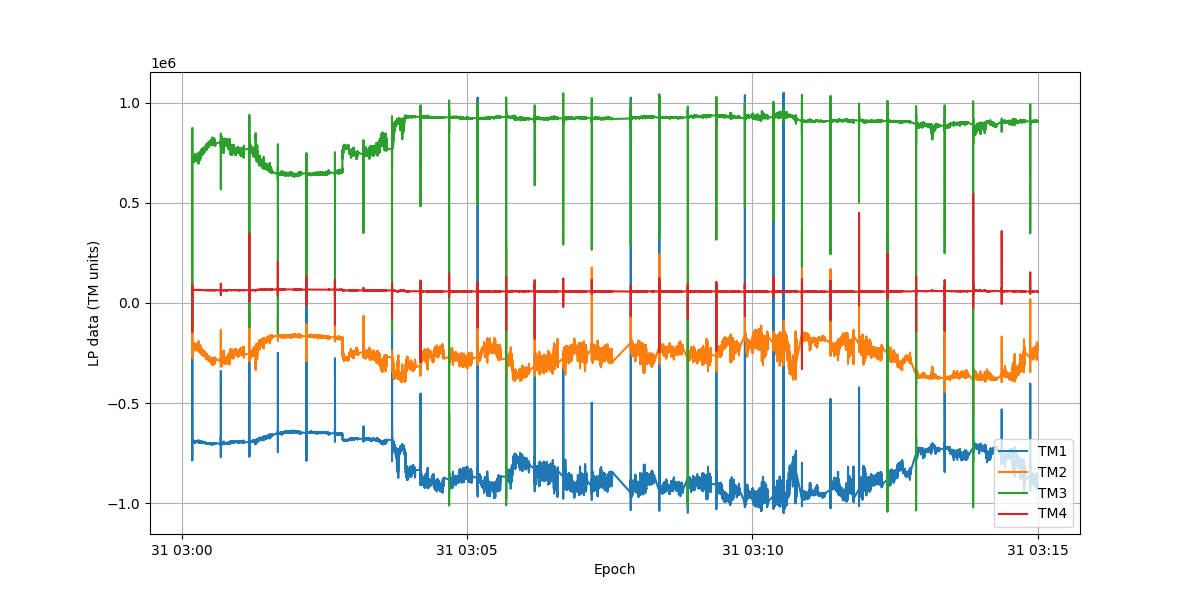

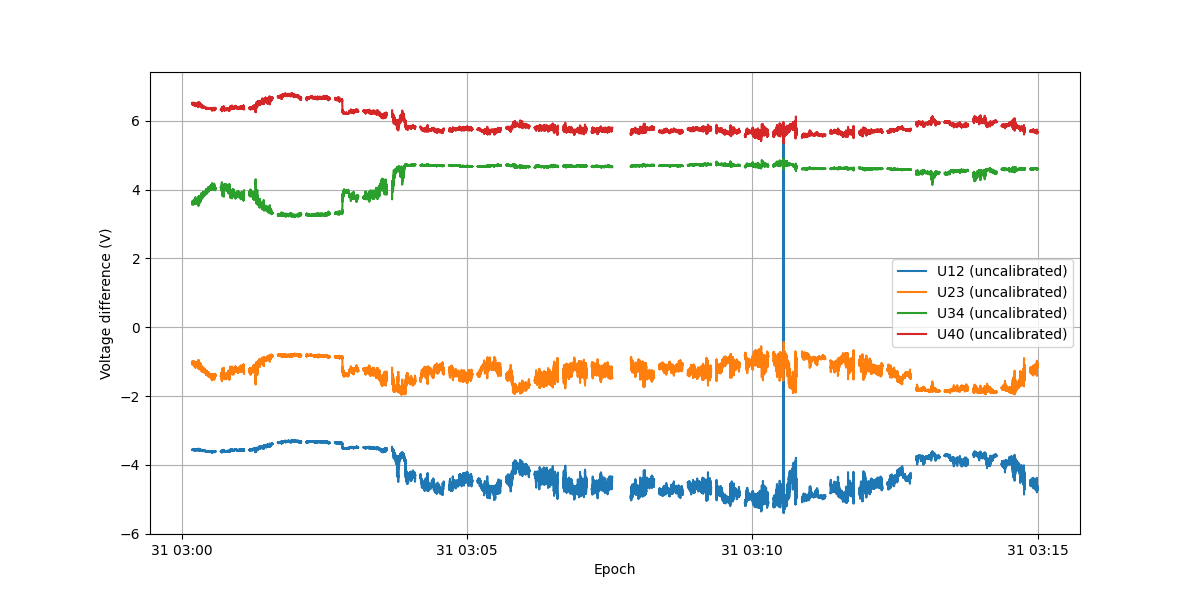

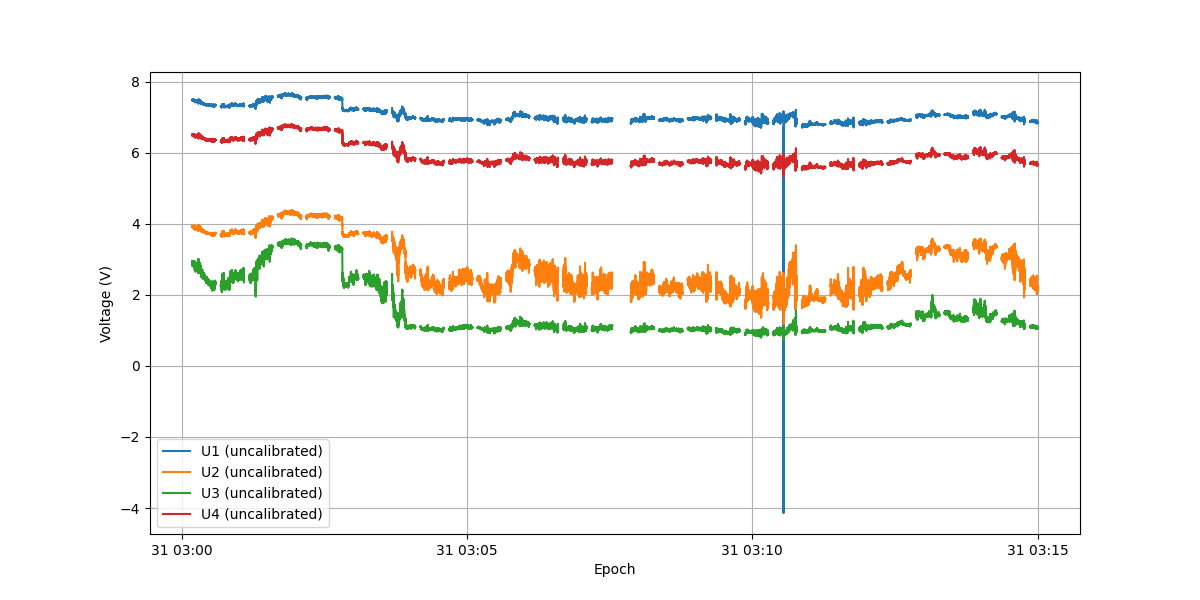

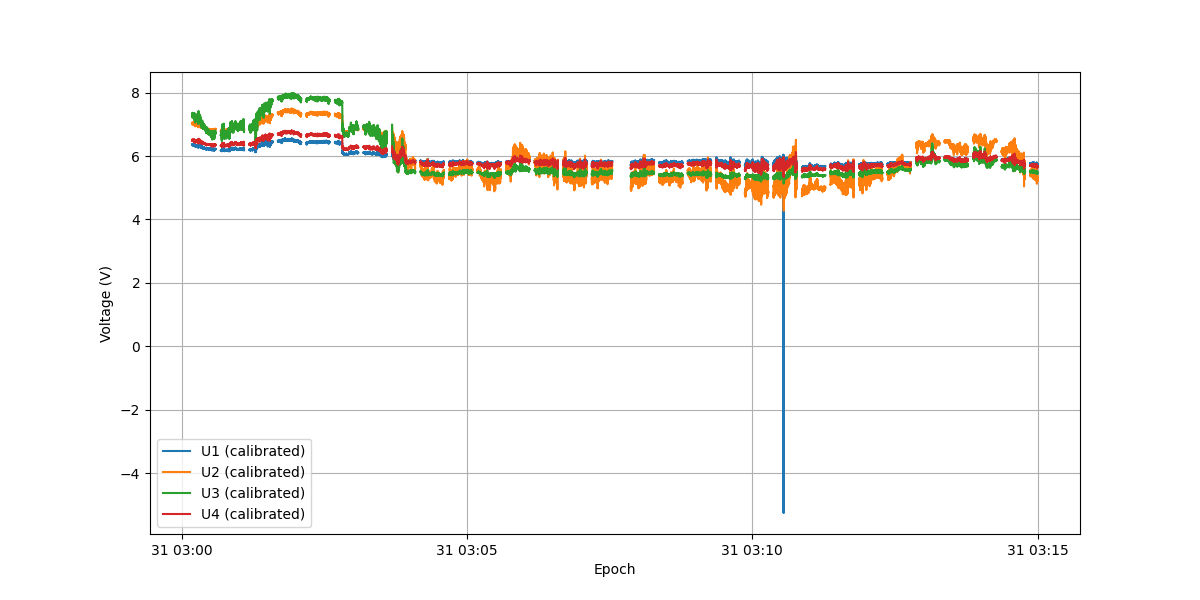

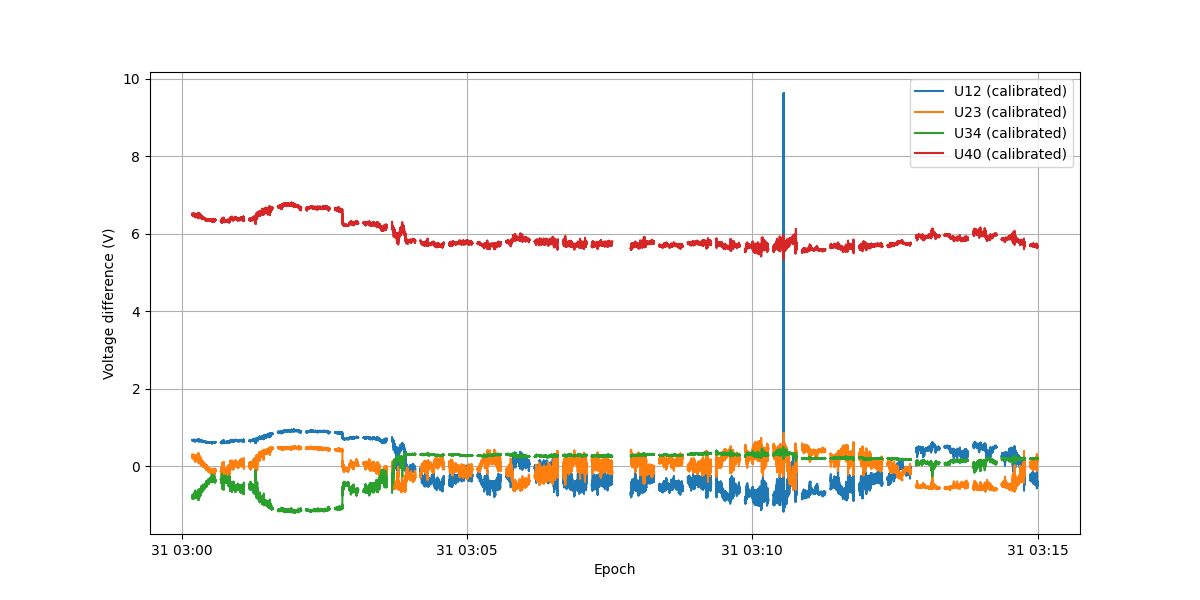

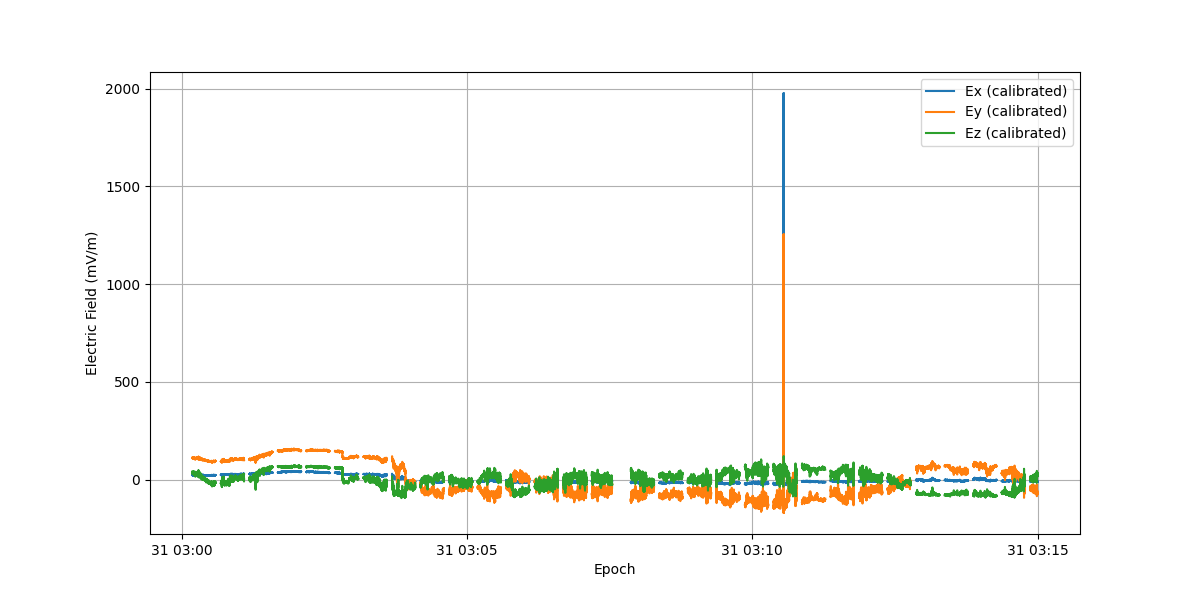

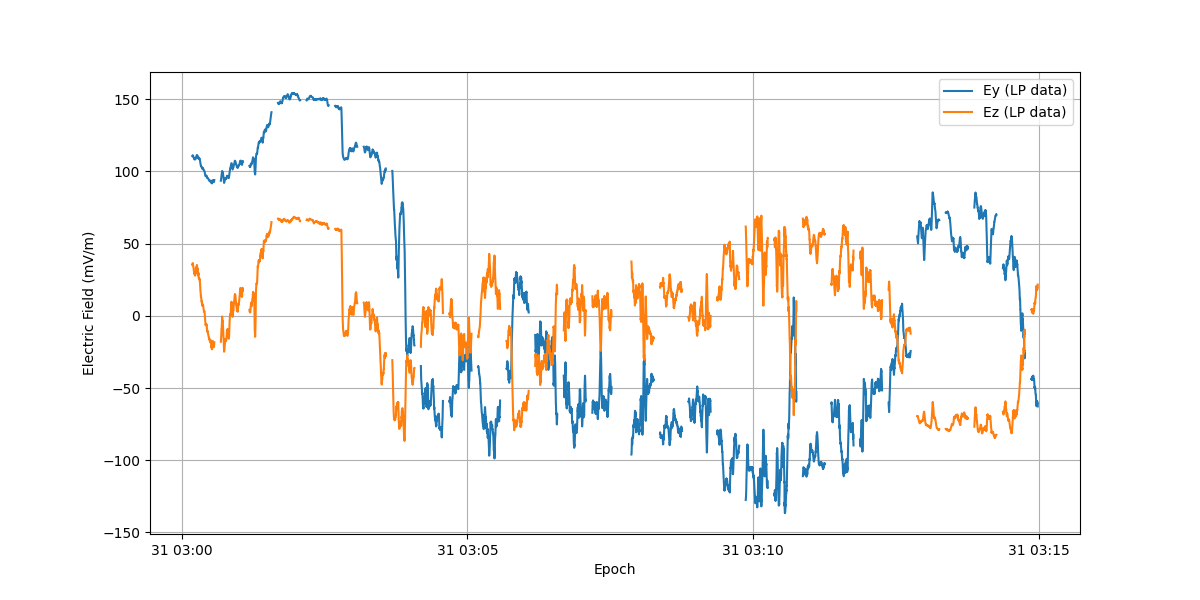

In [22]:
# Get E field for 31/03/2025

avg_value_correction = True
# Start and end dates for filtering
start_date = dt.datetime(2025, 3, 31, 3, 0, 0)
end_date = dt.datetime(2025, 3, 31, 3, 15, 0)

TM2diff = np.array([5.15*1e-6, 4.97*1e-6, 5.07*1e-6, 9.94*1e-5]) # Coefficients to go from telemetry units to differentials

lp_cdf = cdflib.CDF('../DATA/JUICE_L1a_RPWI-LP-SID1_RICH_DE763_SNAP_20250331T030011_V02.cdf')

lp_epoch = lp_cdf.varget('Epoch')
lp_epoch = cdflib.cdfepoch.to_datetime(lp_epoch)
lp_epoch = np.array(lp_epoch, dtype='datetime64[ms]').astype('O')
TM1 = lp_cdf.varget('LP_DATA')[:, 0]
TM2 = lp_cdf.varget('LP_DATA')[:, 1]
TM3 = lp_cdf.varget('LP_DATA')[:, 2]
TM4 = lp_cdf.varget('LP_DATA')[:, 3]

# Filter the TM lists and epoch list
filtered_indices = [i for i, t in enumerate(lp_epoch) if start_date <= t <= end_date]
lp_epoch = lp_epoch[filtered_indices]
TM1 = TM1[filtered_indices]
TM2 = TM2[filtered_indices]
TM3 = TM3[filtered_indices]
TM4 = TM4[filtered_indices]

plt.figure(figsize=(12, 6))
plt.plot(lp_epoch, TM1, label='TM1')
plt.plot(lp_epoch, TM2, label='TM2')
plt.plot(lp_epoch, TM3, label='TM3')
plt.plot(lp_epoch, TM4, label='TM4')
plt.xlabel('Epoch')
plt.ylabel('LP data (TM units)')
plt.legend()
plt.grid()
plt.show()

U12 = TM1 * TM2diff[0]
U23 = TM2 * TM2diff[1]
U34 = TM3 * TM2diff[2]
U40 = TM4 * TM2diff[3]

U12 = filter_out_start_config_noise(U12, lp_epoch)
U23 = filter_out_start_config_noise(U23, lp_epoch)
U34 = filter_out_start_config_noise(U34, lp_epoch)
U40 = filter_out_start_config_noise(U40, lp_epoch)

plt.figure(figsize=(12, 6)) 
plt.plot(lp_epoch, U12, label='U12 (uncalibrated)')
plt.plot(lp_epoch, U23, label='U23 (uncalibrated)')
plt.plot(lp_epoch, U34, label='U34 (uncalibrated)')
plt.plot(lp_epoch, U40, label='U40 (uncalibrated)')
plt.xlabel('Epoch')
plt.ylabel('Voltage difference (V)')
plt.legend()
plt.grid()
plt.show()

U1, U2, U3, U4 = multiply_lists_by_44matrix(U12, U23, U34, U40, diff2volt)

plt.figure(figsize=(12, 6))
plt.plot(lp_epoch, U1, label='U1 (uncalibrated)')
plt.plot(lp_epoch, U2, label='U2 (uncalibrated)')
plt.plot(lp_epoch, U3, label='U3 (uncalibrated)')
plt.plot(lp_epoch, U4, label='U4 (uncalibrated)')
plt.xlabel('Epoch')
plt.ylabel('Voltage (V)')
plt.legend()
plt.grid()
plt.show()

if avg_value_correction:
    mean_diff_U1 = np.nanmean(np.array(U4) - np.array(U1))
    mean_diff_U2 = np.nanmean(np.array(U4) - np.array(U2))
    mean_diff_U3 = np.nanmean(np.array(U4) - np.array(U3))

    U1 = np.array([float(u) + float(mean_diff_U1) for u in U1])
    U2 = np.array([float(u) + float(mean_diff_U2) for u in U2])
    U3 = np.array([float(u) + float(mean_diff_U3) for u in U3])

plt.figure(figsize=(12, 6))
plt.plot(lp_epoch, U1, label='U1 (calibrated)')
plt.plot(lp_epoch, U2, label='U2 (calibrated)')
plt.plot(lp_epoch, U3, label='U3 (calibrated)')
plt.plot(lp_epoch, U4, label='U4 (calibrated)')
plt.xlabel('Epoch')
plt.ylabel('Voltage (V)')
plt.legend()
plt.grid()
plt.show()

U12, U23, U34, U40 = multiply_lists_by_44matrix(U1, U2, U3, U4, volt2diff)

plt.figure(figsize=(12, 6))
plt.plot(lp_epoch, U12, label='U12 (calibrated)')
plt.plot(lp_epoch, U23, label='U23 (calibrated)')
plt.plot(lp_epoch, U34, label='U34 (calibrated)')
plt.plot(lp_epoch, U40, label='U40 (calibrated)')
plt.xlabel('Epoch')
plt.ylabel('Voltage difference (V)')
plt.legend()
plt.grid()
plt.show()

Ex, Ey, Ez = multiply_lists_by_33matrix(U12, U23, U34, volt2E)

plt.figure(figsize=(12, 6))
plt.plot(lp_epoch, Ex*1e3, label='Ex (calibrated)')
plt.plot(lp_epoch, Ey*1e3, label='Ey (calibrated)')
plt.plot(lp_epoch, Ez*1e3, label='Ez (calibrated)')
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.legend()
plt.grid()
plt.show()

nb_points_avg = 1000

# Smooth E-field data using a 10-point rolling average
Ex_smooth = np.convolve(Ex, np.ones(nb_points_avg)/nb_points_avg, mode='valid')
Ey_smooth = np.convolve(Ey, np.ones(nb_points_avg)/nb_points_avg, mode='valid')
Ez_smooth = np.convolve(Ez, np.ones(nb_points_avg)/nb_points_avg, mode='valid')

# Adjust the epoch to match the smoothed data length
lp_epoch_smooth = lp_epoch[:len(Ex_smooth)]

plt.figure(figsize=(12, 6))
#plt.plot(lp_epoch_smooth, Ex_smooth*1e3, label='Ex (smoothed)')
plt.plot(lp_epoch_smooth, Ey_smooth*1e3, label='Ey (LP data)')
plt.plot(lp_epoch_smooth, Ez_smooth*1e3, label='Ez (LP data)')
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.legend()
plt.grid()
plt.show()

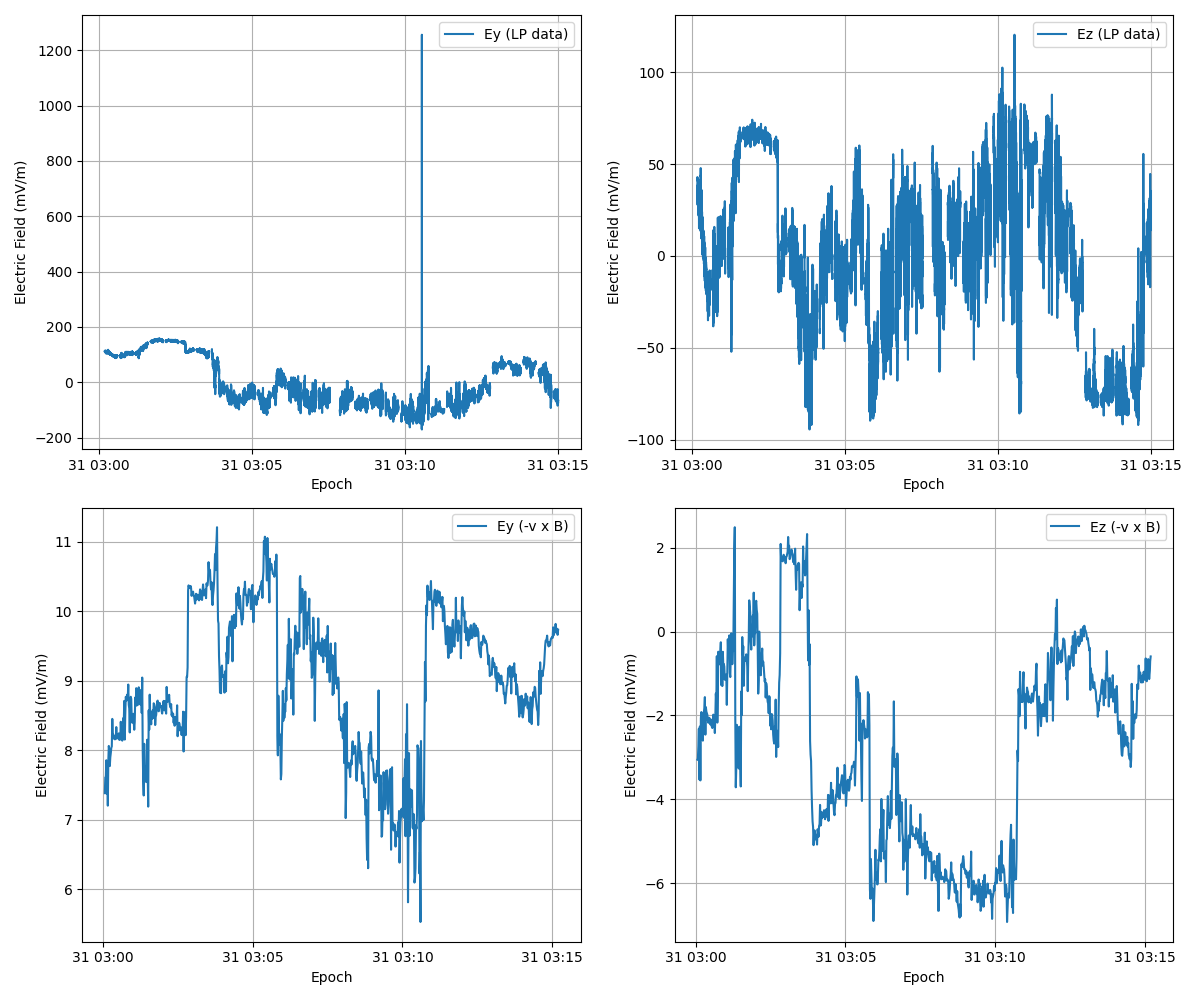

In [ ]:
# Plot LP data next to - v cross B data for 31/03/2025

plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
plt.plot(lp_epoch, Ey*1e3, label='Ey (LP data)')
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.legend()
plt.grid()

plt.subplot(2, 2, 2)
plt.plot(lp_epoch, Ez*1e3, label='Ez (LP data)')
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.legend()
plt.grid()

plt.subplot(2, 2, 3)
plt.plot(jmag_epoch, EyvCB*1e3, label='Ey (-v x B)')
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.legend()
plt.grid()

plt.subplot(2, 2, 4)
plt.plot(jmag_epoch, EzvCB*1e3, label='Ez (-v x B)')
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

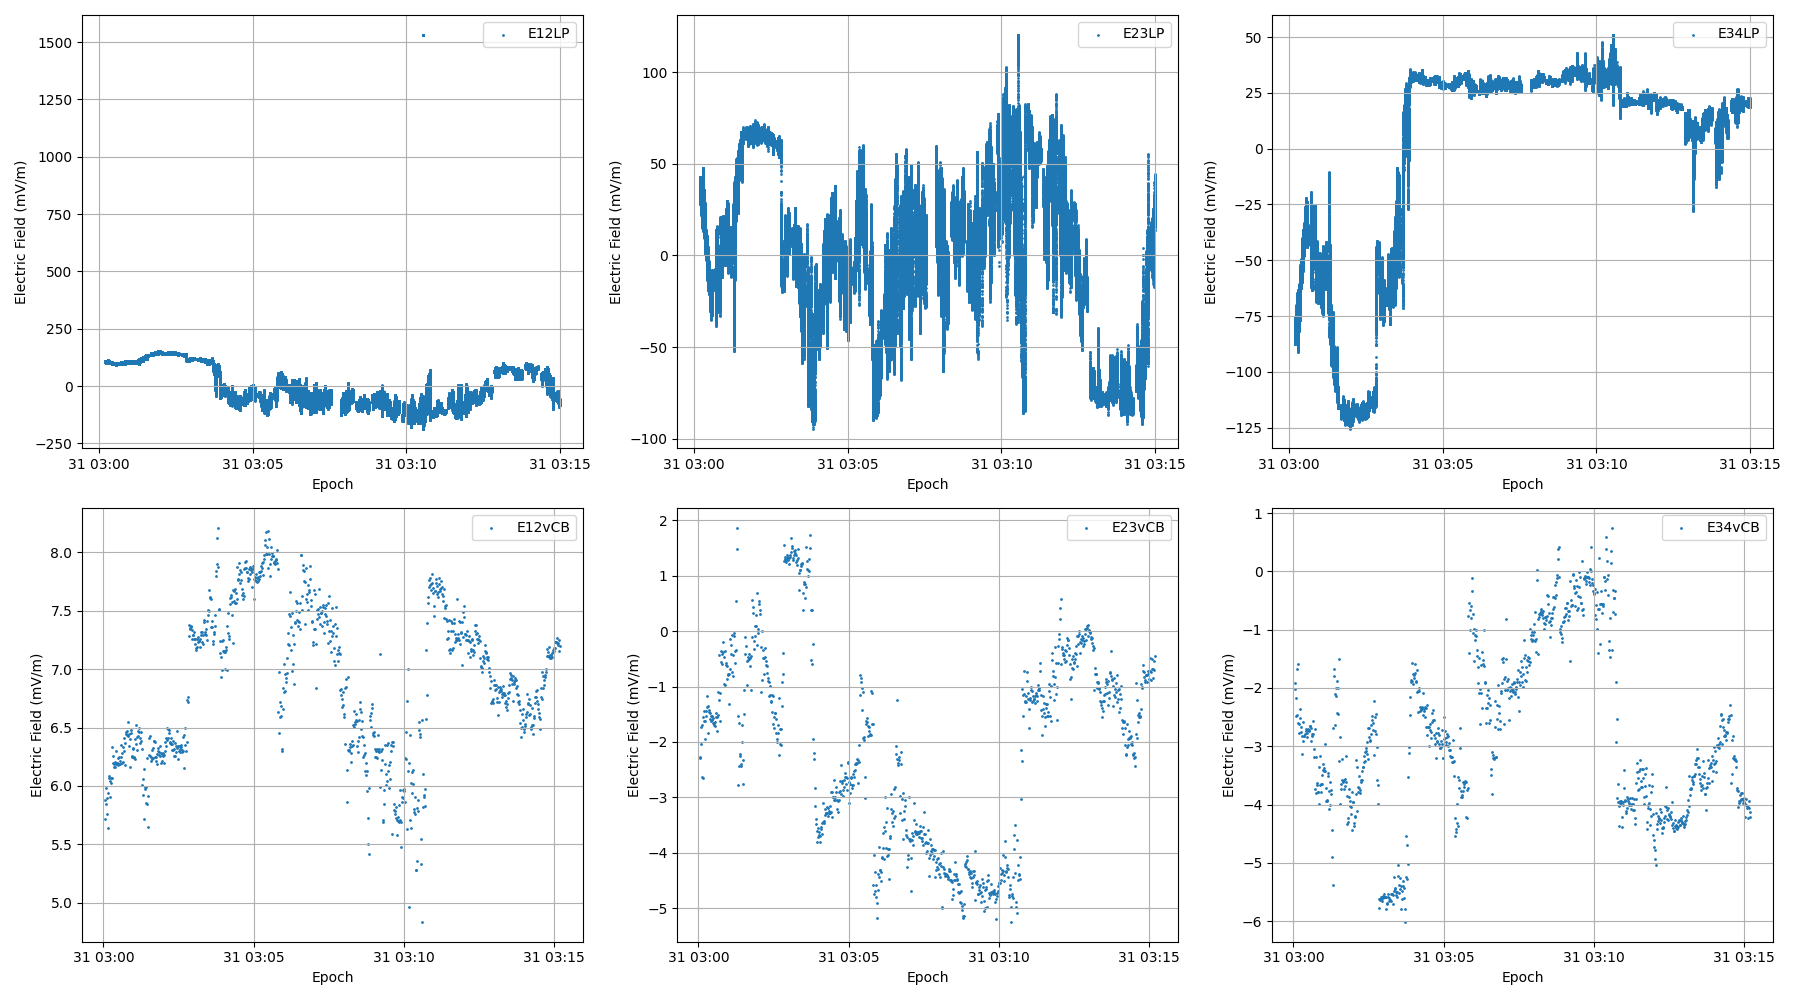

In [19]:
# Trying to look at data in the LP probe frame for 31/03/2025

E12vCB, E23vCB, E34vCB = multiply_lists_by_33matrix(ExvCB, EyvCB, EzvCB, E2volt)
E12vCB = E12vCB / probe_dist[0]
E23vCB = E23vCB / probe_dist[1]
E34vCB = E34vCB / probe_dist[2]

E12LP, E23LP, E34LP = multiply_lists_by_33matrix(Ex, Ey, Ez, E2volt)
E12LP = E12LP / probe_dist[0]
E23LP = E23LP / probe_dist[1]
E34LP = E34LP / probe_dist[2]

plt.figure(figsize=(18, 10))

plt.subplot(2, 3, 1)
plt.scatter(lp_epoch, E12LP*1e3, label='E12LP', s=1)
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.legend()
plt.grid()

plt.subplot(2, 3, 2)
plt.scatter(lp_epoch, E23LP*1e3, label='E23LP', s=1)
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.legend()
plt.grid()

plt.subplot(2, 3, 3)
plt.scatter(lp_epoch, E34LP*1e3, label='E34LP', s=1)
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.legend()
plt.grid()

plt.subplot(2, 3, 4)
plt.scatter(jmag_epoch, E12vCB*1e3, label='E12vCB', s=1)
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.legend()
plt.grid()

plt.subplot(2, 3, 5)
plt.scatter(jmag_epoch, E23vCB*1e3, label='E23vCB', s=1)
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.legend()
plt.grid()

plt.subplot(2, 3, 6)
plt.scatter(jmag_epoch, E34vCB*1e3, label='E34vCB', s=1)
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

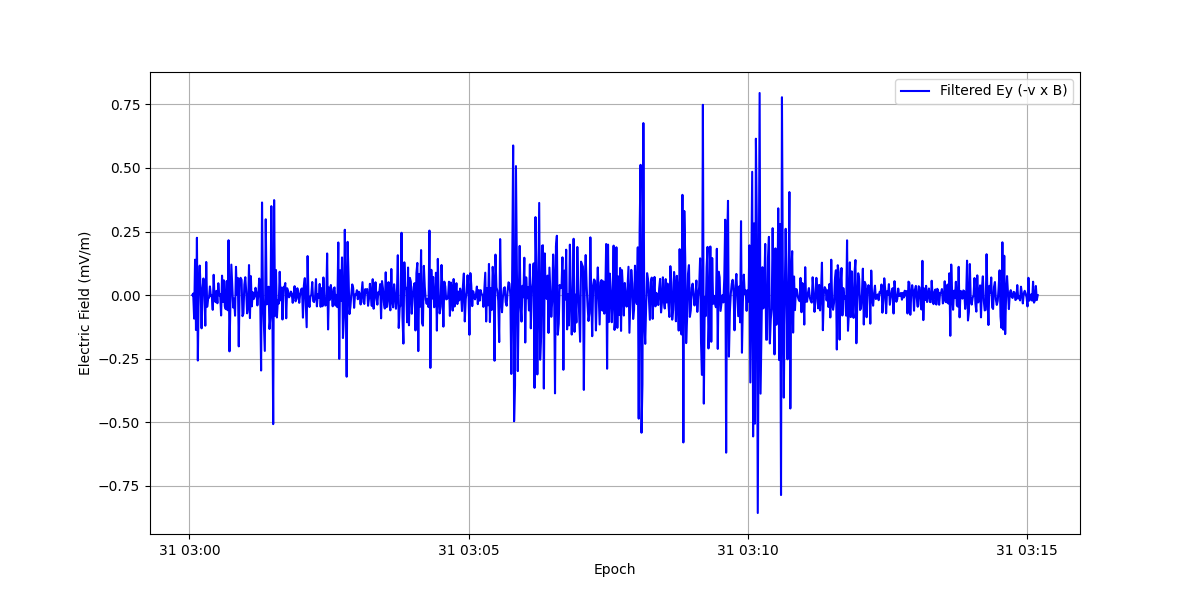

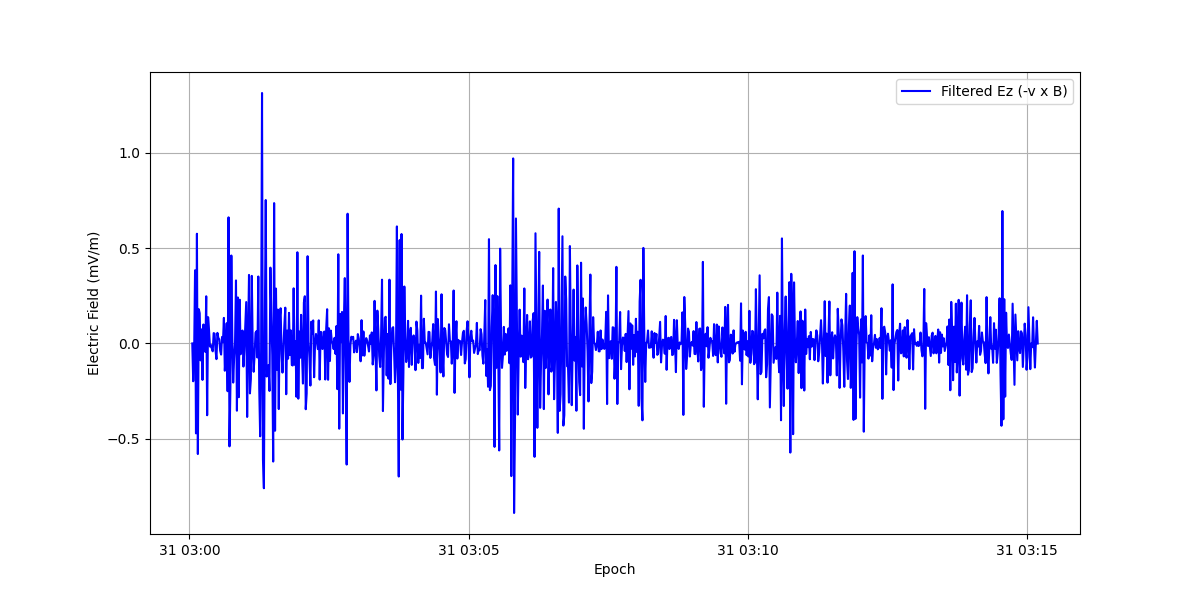

In [ ]:
# Trying a high-pass filter on the v cross B data

cutoff = 0.2 # Cutoff frequency in Hz
order = 5
sampling_rate = 1 # Hz

# Create a uniformly spaced time array starting from jmag_epoch[0]
start_time = jmag_epoch[0]
end_time = jmag_epoch[-1]
uniform_times = np.arange(
    start_time, end_time + np.timedelta64(1, 's'),
    np.timedelta64(1, 's')
).astype('datetime64[s]').astype('O')

# Interpolate EyvCB and EzvCB onto the uniform time grid
jmag_seconds = np.array([(t - start_time).total_seconds() for t in jmag_epoch])
uniform_seconds = np.array([(t - start_time).total_seconds() for t in uniform_times])

interp_Ey = interp1d(jmag_seconds, EyvCB, kind='linear', bounds_error=False, fill_value='extrapolate')
interp_Ez = interp1d(jmag_seconds, EzvCB, kind='linear', bounds_error=False, fill_value='extrapolate')

EyvCB_uniform = interp_Ey(uniform_seconds)
EzvCB_uniform = interp_Ez(uniform_seconds)

# Replace the original arrays with the uniformly sampled ones
jmag_epoch = uniform_times
EyvCB = EyvCB_uniform
EzvCB = EzvCB_uniform

# Filter the Ey and Ez data
EyvCB_filtered = highpass_filter(EyvCB, cutoff, sampling_rate, order)
EzvCB_filtered = highpass_filter(EzvCB, cutoff, sampling_rate, order)

# Plot the filtered Ey and Ez data
plt.figure(figsize=(12, 6))
plt.plot(jmag_epoch, EyvCB_filtered*1e3, label='Filtered Ey (-v x B)', color = 'blue')
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(jmag_epoch, EzvCB_filtered*1e3, label='Filtered Ez (-v x B)', color = 'blue')
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.legend()
plt.grid()
plt.show()

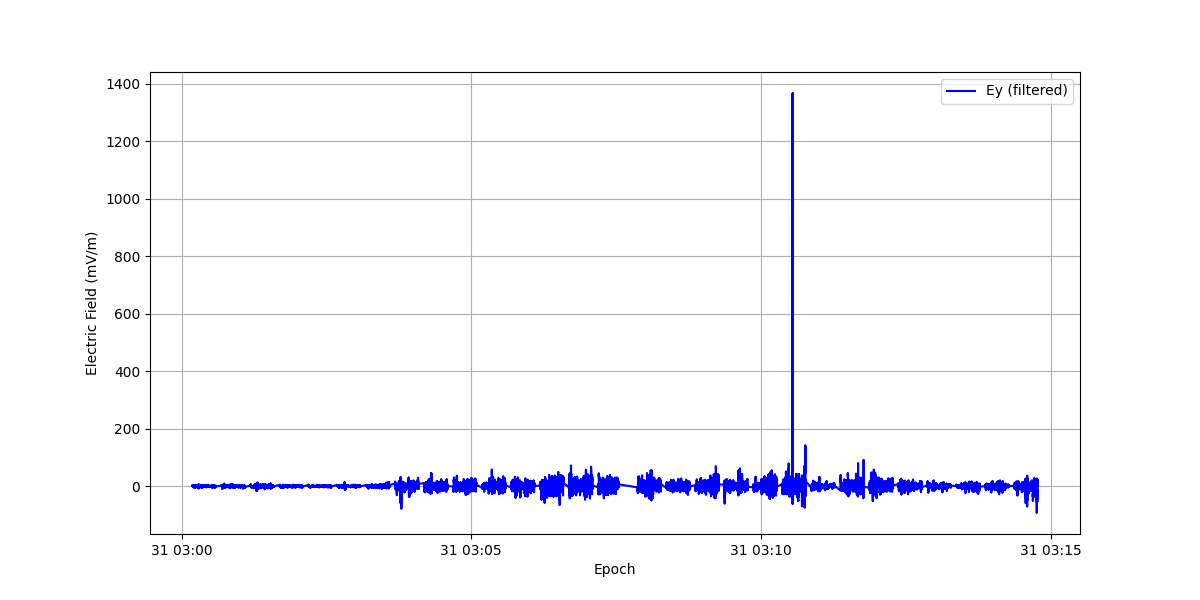

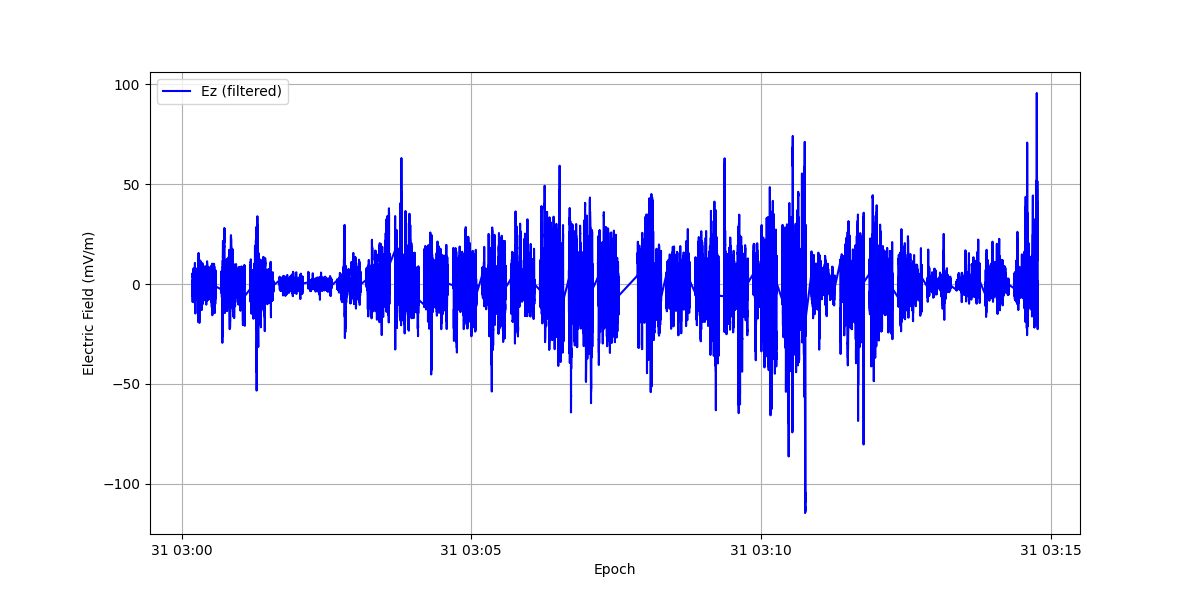

In [24]:
# Trying a high-pass filter on the LP E-field data

cutoff = 0.2  # Desired cutoff frequency of the filter, Hz
order = 5

# Separate the data into different sections based on time gaps larger than 1 second
sections = []
current_section = [0]  # Start with the first index

for i in range(1, len(lp_epoch)):
    time_diff = (lp_epoch[i] - lp_epoch[i - 1]).total_seconds()
    if time_diff > 0.1:
        sections.append(current_section)
        current_section = [i]
    else:
        current_section.append(i)

# Create separate lists for Ex, Ey, Ez based on the sections
Ex_sections = [Ex[section] for section in sections]
Ey_sections = [Ey[section] for section in sections]
Ez_sections = [Ez[section] for section in sections]
lp_epoch_sections = [lp_epoch[section] for section in sections]

# Resample each section to have a constant sampling rate (1 ms steps)
resampled_Ex_sections = []
resampled_Ey_sections = []
resampled_Ez_sections = []
resampled_lp_epoch_sections = []

for epoch_section, Ex_section, Ey_section, Ez_section in zip(lp_epoch_sections, Ex_sections, Ey_sections, Ez_sections):
    # Create a uniformly spaced time array (1 ms steps)
    start_time = epoch_section[0]
    end_time = epoch_section[-1]
    num_points = int((end_time - start_time).total_seconds() * 1000) + 1
    uniform_times = np.array([start_time + dt.timedelta(milliseconds=i) for i in range(num_points)], dtype='O')

    # Convert times to seconds since start for interpolation
    epoch_seconds = np.array([(t - start_time).total_seconds() for t in epoch_section])
    uniform_seconds = np.array([(t - start_time).total_seconds() for t in uniform_times])

    # Interpolate Ex, Ey, Ez onto the uniform time grid
    interp_Ex = interp1d(epoch_seconds, Ex_section, kind='linear', bounds_error=False, fill_value='extrapolate')
    interp_Ey = interp1d(epoch_seconds, Ey_section, kind='linear', bounds_error=False, fill_value='extrapolate')
    interp_Ez = interp1d(epoch_seconds, Ez_section, kind='linear', bounds_error=False, fill_value='extrapolate')

    Ex_uniform = interp_Ex(uniform_seconds)
    Ey_uniform = interp_Ey(uniform_seconds)
    Ez_uniform = interp_Ez(uniform_seconds)

    resampled_Ex_sections.append(Ex_uniform)
    resampled_Ey_sections.append(Ey_uniform)
    resampled_Ez_sections.append(Ez_uniform)
    resampled_lp_epoch_sections.append(uniform_times)

# Replace the original sections with the resampled ones
Ex_sections = resampled_Ex_sections
Ey_sections = resampled_Ey_sections
Ez_sections = resampled_Ez_sections
lp_epoch_sections = resampled_lp_epoch_sections

sampling_rate = 1000  # Hz (since we now have 1 ms steps)

# Apply the high-pass filter to each section individually and then concatenate the results
Ex_filtered_sections = []
Ey_filtered_sections = []
Ez_filtered_sections = []
lp_epoch_filtered_sections = []

for Ex_section, Ey_section, Ez_section, lp_epoch_section in zip(Ex_sections, Ey_sections, Ez_sections, lp_epoch_sections):
    valid_indices = ~np.isnan(Ex_section) & ~np.isnan(Ey_section) & ~np.isnan(Ez_section)
    Ex_filtered = highpass_filter(Ex_section[valid_indices], cutoff, sampling_rate, order)
    Ey_filtered = highpass_filter(Ey_section[valid_indices], cutoff, sampling_rate, order)
    Ez_filtered = highpass_filter(Ez_section[valid_indices], cutoff, sampling_rate, order)
    lp_epoch_filtered = lp_epoch_section[valid_indices]
    
    Ex_filtered_sections.append(Ex_filtered)
    Ey_filtered_sections.append(Ey_filtered)
    Ez_filtered_sections.append(Ez_filtered)
    lp_epoch_filtered_sections.append(lp_epoch_filtered)

# Concatenate the filtered sections back into a single array
Ex_filtered_full = np.concatenate(Ex_filtered_sections)
Ey_filtered_full = np.concatenate(Ey_filtered_sections)
Ez_filtered_full = np.concatenate(Ez_filtered_sections)
lp_epoch_filtered_full = np.concatenate(lp_epoch_filtered_sections)

plt.figure(figsize=(12, 6))
plt.plot(lp_epoch_filtered_full, Ey_filtered_full*1e3, label='Ey (filtered)', color = 'blue')
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(lp_epoch_filtered_full, Ez_filtered_full*1e3, label='Ez (filtered)', color = 'blue')
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.legend()
plt.grid()
plt.show()

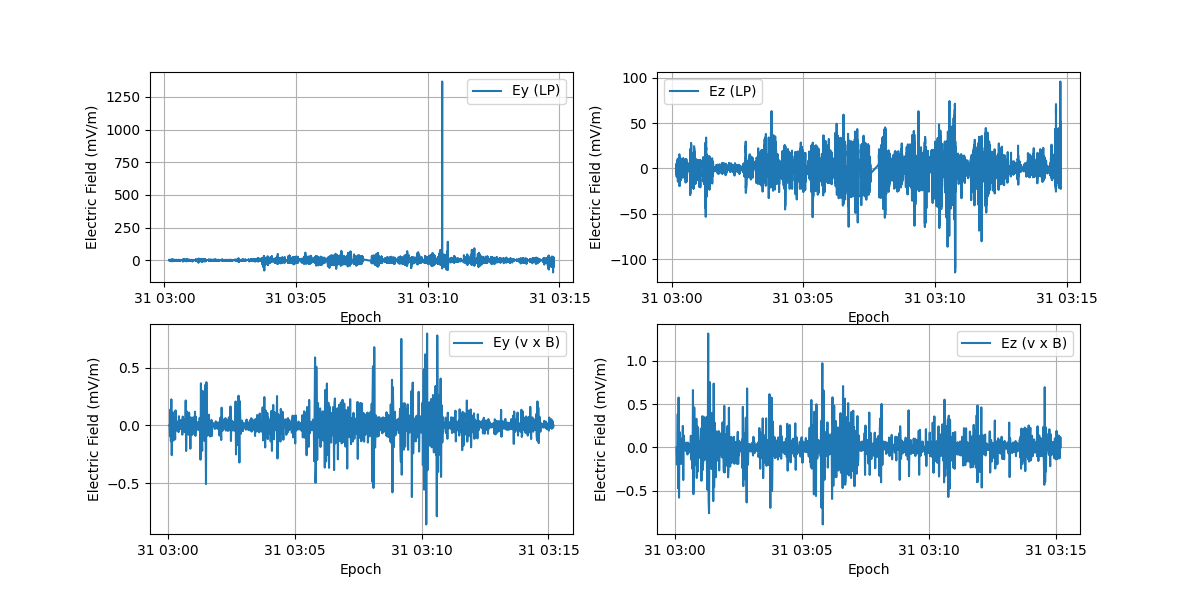

In [26]:
# Plot filtered E-field data

plt.figure(figsize=(12, 6))

plt.subplot(2, 2, 1)
plt.plot(lp_epoch_filtered_full, Ey_filtered_full*1e3, label='Ey (LP)')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.grid()

plt.subplot(2, 2, 2)
plt.plot(lp_epoch_filtered_full, Ez_filtered_full*1e3, label='Ez (LP)')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.grid()

plt.subplot(2, 2, 3)
plt.plot(jmag_epoch, EyvCB_filtered*1e3, label='Ey (v x B)')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.grid()

plt.subplot(2, 2, 4)
plt.plot(jmag_epoch, EzvCB_filtered*1e3, label='Ez (v x B)')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.grid()

plt.show()

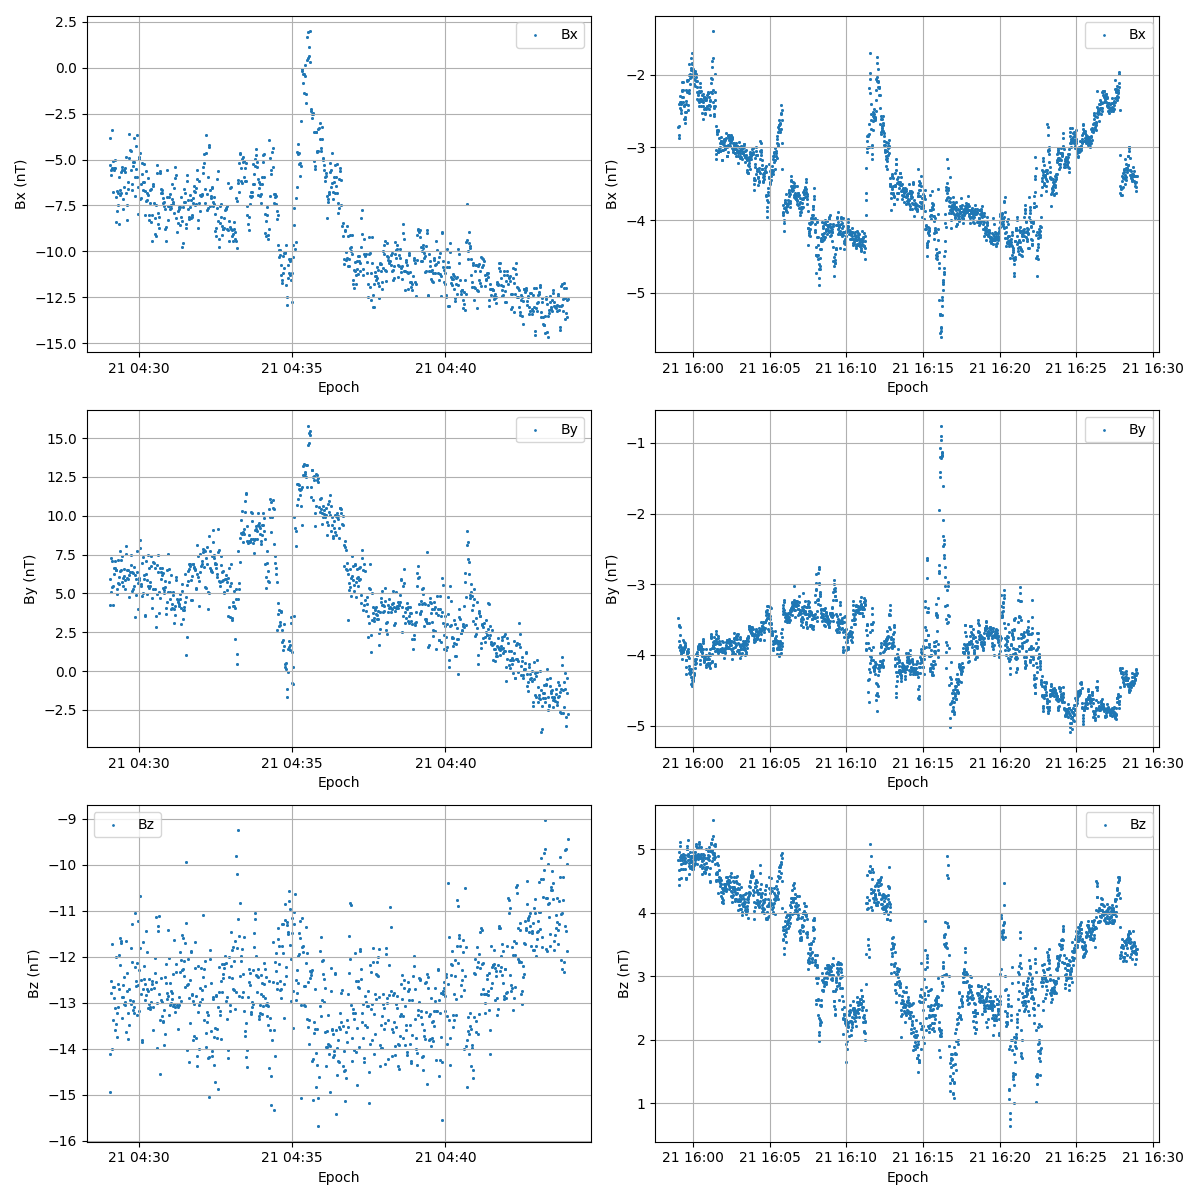

In [4]:
# Reading jmag_echoed data from 21/08/2024

jmag_cdf = cdflib.CDF('../DATA/jmag_echoed/2024/08/21/JUICE_LU_RPWI-PPTD-LWYRPW79700_20240821T042902_V01.cdf')

NMD = jmag_cdf.varget('NMD')
jmag_epoch = jmag_cdf.varget('Epoch')
jmag_epoch = cdflib.cdfepoch.to_datetime(jmag_epoch)
jmag_epoch = np.array(jmag_epoch, dtype='datetime64[ms]').astype('O')

# Find the index where the separation occurs
epoch_diffs = np.diff(jmag_epoch)
separation_index = np.argmax(epoch_diffs > dt.timedelta(hours=1)) + 1

jmag_epoch1 = jmag_epoch[:separation_index]
jmag_epoch2 = jmag_epoch[separation_index:]

Bx = extract_double_from_columns(NMD, 9, 17)
By = extract_double_from_columns(NMD, 17, 25)
Bz = extract_double_from_columns(NMD, 25, 33)

Bx = np.where(np.abs(Bx) < 1e-9, np.nan, Bx)
By = np.where(np.abs(By) < 1e-9, np.nan, By)
Bz = np.where(np.abs(Bz) < 1e-9, np.nan, Bz)

# Rotate the magnetic field vectors to the JUICE frame
Bx_rot = R_JMAG[0,0]*Bx + R_JMAG[0,1]*By + R_JMAG[0,2]*Bz
By_rot = R_JMAG[1,0]*Bx + R_JMAG[1,1]*By + R_JMAG[1,2]*Bz
Bz_rot = R_JMAG[2,0]*Bx + R_JMAG[2,1]*By + R_JMAG[2,2]*Bz
Bx = Bx_rot
By = By_rot
Bz = Bz_rot

Bx1 = Bx[:separation_index]
By1 = By[:separation_index]
Bz1 = Bz[:separation_index]

Bx2 = Bx[separation_index:]
By2 = By[separation_index:]
Bz2 = Bz[separation_index:]

plt.figure(figsize=(12, 12))

plt.subplot(3, 2, 1)
plt.scatter(jmag_epoch1, Bx1, label='Bx', s = 1)
plt.xlabel('Epoch')
plt.ylabel('Bx (nT)')
plt.grid()
plt.legend()

plt.subplot(3, 2, 2)
plt.scatter(jmag_epoch2, Bx2, label='Bx', s = 1)
plt.xlabel('Epoch')
plt.ylabel('Bx (nT)')
plt.grid()
plt.legend()

plt.subplot(3, 2, 3)
plt.scatter(jmag_epoch1, By1, label='By', s = 1)
plt.xlabel('Epoch')
plt.ylabel('By (nT)')
plt.grid()
plt.legend()

plt.subplot(3, 2, 4)
plt.scatter(jmag_epoch2, By2, label='By', s = 1)
plt.xlabel('Epoch')
plt.ylabel('By (nT)')
plt.grid()
plt.legend()

plt.subplot(3, 2, 5)
plt.scatter(jmag_epoch1, Bz1, label='Bz', s = 1)
plt.xlabel('Epoch')
plt.ylabel('Bz (nT)')
plt.grid()
plt.legend()

plt.subplot(3, 2, 6)
plt.scatter(jmag_epoch2, Bz2, label='Bz', s = 1)
plt.xlabel('Epoch')
plt.ylabel('Bz (nT)')
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

Distance from JUICE to Sun: 151281095.07343757 km
Distance from WIND to Sun: 149915450.1930079 km
Delta time: -1.191226149614406 hours


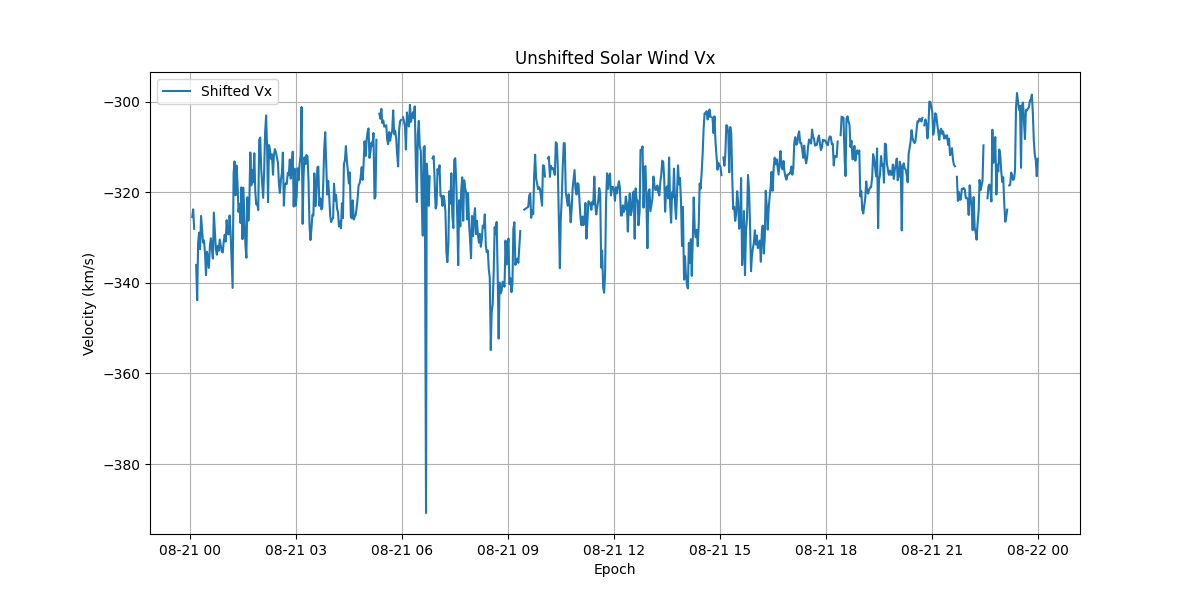

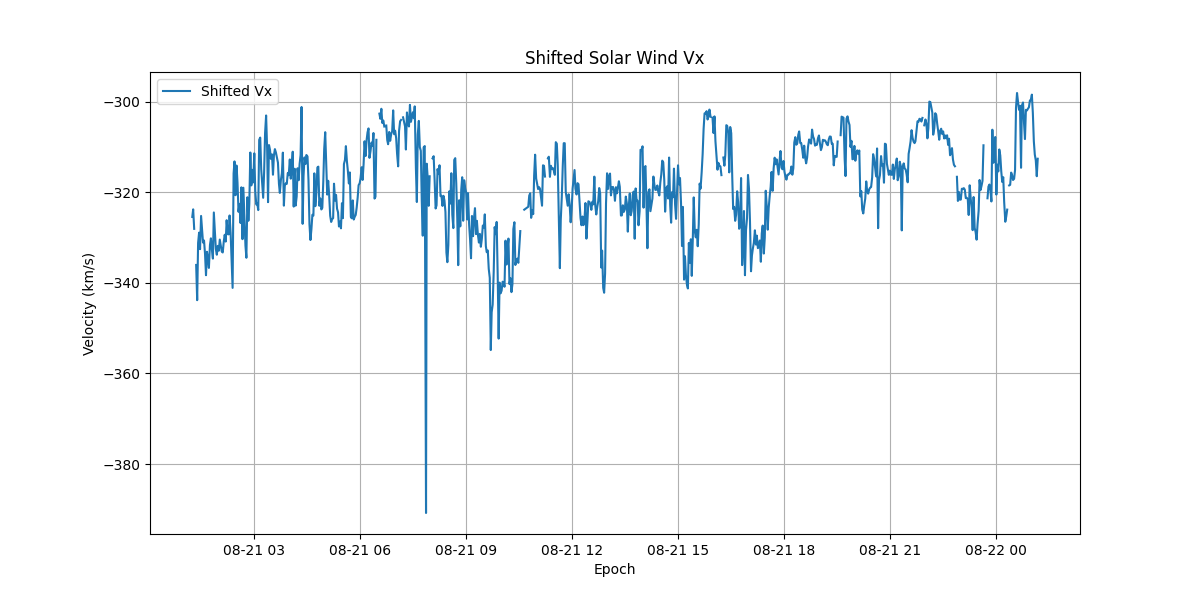

In [5]:
# Get and shift SW data from 2024/08/21
# We are only taking data from 15:55 to 16:30 because that is when JUICE was in the solar wind

wind_cdf = cdflib.CDF('../DATA/wi_k0s_swe_20240821000335_20240821235902_cdaweb.cdf')

V_GSE = wind_cdf.varget('V_GSE')
WIND_pos_gse = wind_cdf.varget('SC_pos_gse')
wind_epoch = wind_cdf.varget('Epoch')
wind_epoch = cdflib.cdfepoch.to_datetime(wind_epoch)
wind_epoch = np.array(wind_epoch, dtype='datetime64[ms]').astype('O')

V_GSE[V_GSE < -1e5] = np.nan # Remove all of the 0 values from the solar wind data
sw_speed = -np.nanmean(V_GSE[:, 0], axis=0) # Get the average speed of the solar wind in km/s during the considered time period

# Load the necessary SPICE kernels
spice.furnsh("../SPICE/JUICE/kernels/mk/juice_ops.tm")

et = spice.str2et("2024-08-21T16:00:00")

pos_earth_j2000, _ = spice.spkpos("EARTH", et, "J2000", "NONE", "SUN")
distance_earth_sun = np.linalg.norm(pos_earth_j2000)

# Getting WIND's distance to the Sun : in GSE, X axis is Sun-Earth direction, 
# so just need to change the X coordinate to recenter the coordinate system on the Sun
WIND_pos_sun_centered_x = WIND_pos_gse[:, 0] - distance_earth_sun

WIND_distance_sun = np.sqrt(WIND_pos_sun_centered_x**2 + WIND_pos_gse[:, 1]**2 + WIND_pos_gse[:, 2]**2)
avrg_WIND_distance_sun = np.nanmean(WIND_distance_sun)

pos_juice_j2000, _ = spice.spkpos("JUICE", et, "J2000", "NONE", "SUN")
distance_juice_sun = np.linalg.norm(pos_juice_j2000)

print(f"Distance from JUICE to Sun: {distance_juice_sun} km")
print(f"Distance from WIND to Sun: {avrg_WIND_distance_sun} km")

delta_distance = avrg_WIND_distance_sun - distance_juice_sun

delta_time = delta_distance / sw_speed
print(f"Delta time: {delta_time/(60*60)} hours")

# Plot before shifting
plt.figure(figsize=(12, 6))
plt.plot(wind_epoch, V_GSE[:, 0], label='Shifted Vx')
plt.title('Unshifted Solar Wind Vx')
plt.xlabel('Epoch')
plt.ylabel('Velocity (km/s)')
plt.legend()
plt.grid()
plt.show()

# Shift the solar wind data to delta_time seconds earlier this way the solar wind data is plotted on the time it reaches JUICE
wind_epoch_shifted = wind_epoch - dt.timedelta(seconds=delta_time)
plt.figure(figsize=(12, 6))
plt.plot(wind_epoch_shifted, V_GSE[:, 0], label='Shifted Vx')
plt.title('Shifted Solar Wind Vx')
plt.xlabel('Epoch')
plt.ylabel('Velocity (km/s)')
plt.legend()
plt.grid()
plt.show()

spice.unload("SPICE/JUICE/kernels/mk/juice_ops.tm")

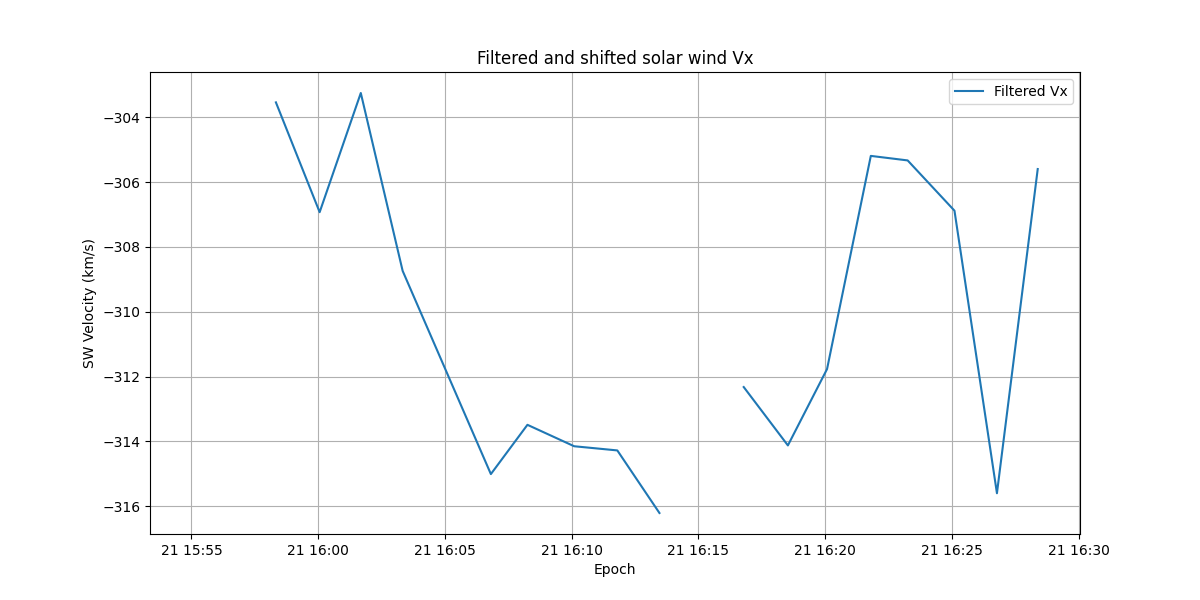

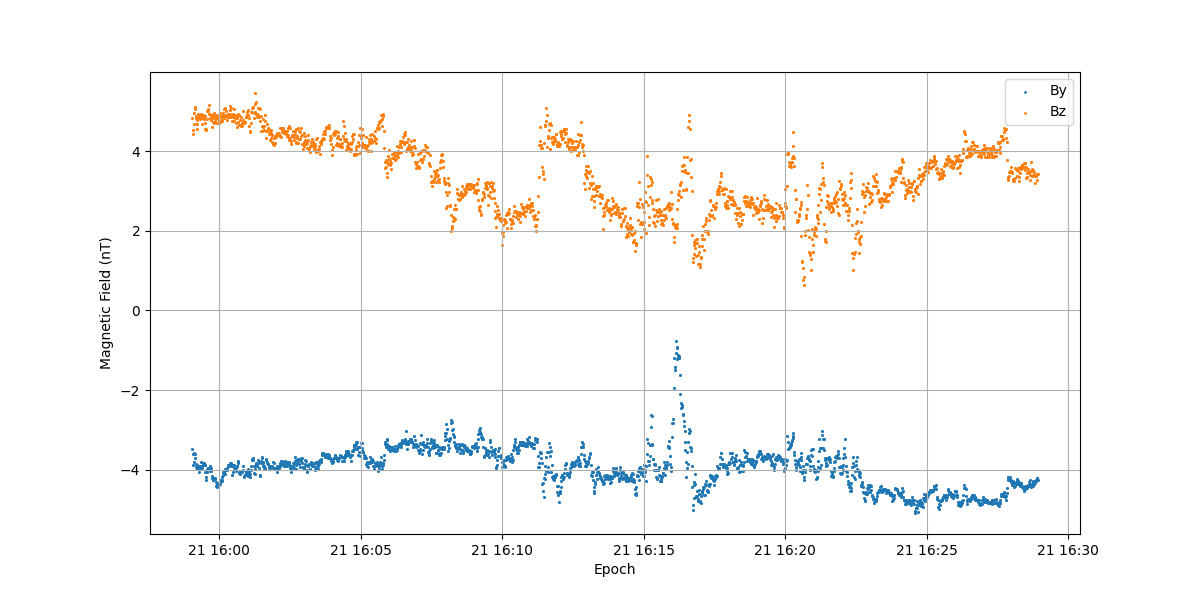

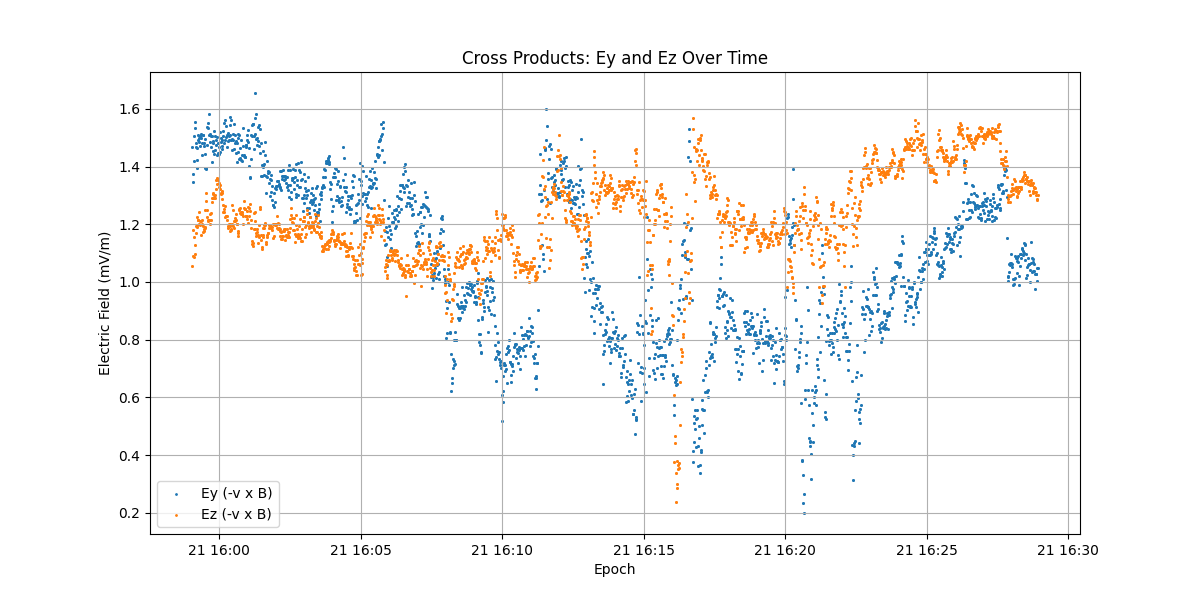

In [6]:
# Calculate - v cross B for 21/08/2024

# X axis for JUICE points away from HGA antenna, so AWAY from the Sun, so SW speed needs to be positive

# Start and end times for the plot of solar wind data
start_time = dt.datetime(2024, 8, 21, 15, 55, 0)
end_time = dt.datetime(2024, 8, 21, 16, 30, 0)

cross_products = np.zeros((len(jmag_epoch2), 3))

# Calculate the cross product of the solar wind velocity and the magnetic field
# For each time step in the JMAG data, we find the closest time step in the shifted solar wind data
for i in range(len(jmag_epoch2)):
    time_diffs = np.abs(wind_epoch_shifted - jmag_epoch2[i])
    sorted_indices = np.argsort(time_diffs)
    
    sw_vx = np.nan
    for idx in sorted_indices:
        if not np.isnan(V_GSE[idx, 0]):
            sw_vx = V_GSE[idx, 0]
            break
    sw_vx = -sw_vx  # In JUICE frame, the velocity is negative
    
    cross_products[i] = [0, -float(-Bz2[i] * sw_vx * 1e-6), -float(By2[i] * sw_vx * 1e-6)]

ExvCB = cross_products[:, 0]
EyvCB = cross_products[:, 1]
EzvCB = cross_products[:, 2]

# Filter the solar wind data for the specified time range
filtered_indices = [i for i, t in enumerate(wind_epoch_shifted) if start_time <= t <= end_time]
wind_epoch_filtered = wind_epoch_shifted[filtered_indices]
V_GSE_filtered = V_GSE[filtered_indices, 0]

# Plot the filtered solar wind data
plt.figure(figsize=(12, 6))
plt.plot(wind_epoch_filtered, V_GSE_filtered, label='Filtered Vx')
plt.title('Filtered and shifted solar wind Vx')
plt.xlabel('Epoch')
plt.ylabel('SW Velocity (km/s)')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(12, 6))
plt.scatter(jmag_epoch2, By2, label='By', s = 1)
plt.scatter(jmag_epoch2, Bz2, label='Bz', s = 1)
plt.xlabel('Epoch')
plt.ylabel('Magnetic Field (nT)')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(12, 6))
plt.scatter(jmag_epoch2, EyvCB*1e3, label='Ey (-v x B)', s=1)
plt.scatter(jmag_epoch2, EzvCB*1e3, label='Ez (-v x B)', s=1)
plt.title('Cross Products: Ey and Ez Over Time')
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.legend()
plt.grid()
plt.show()

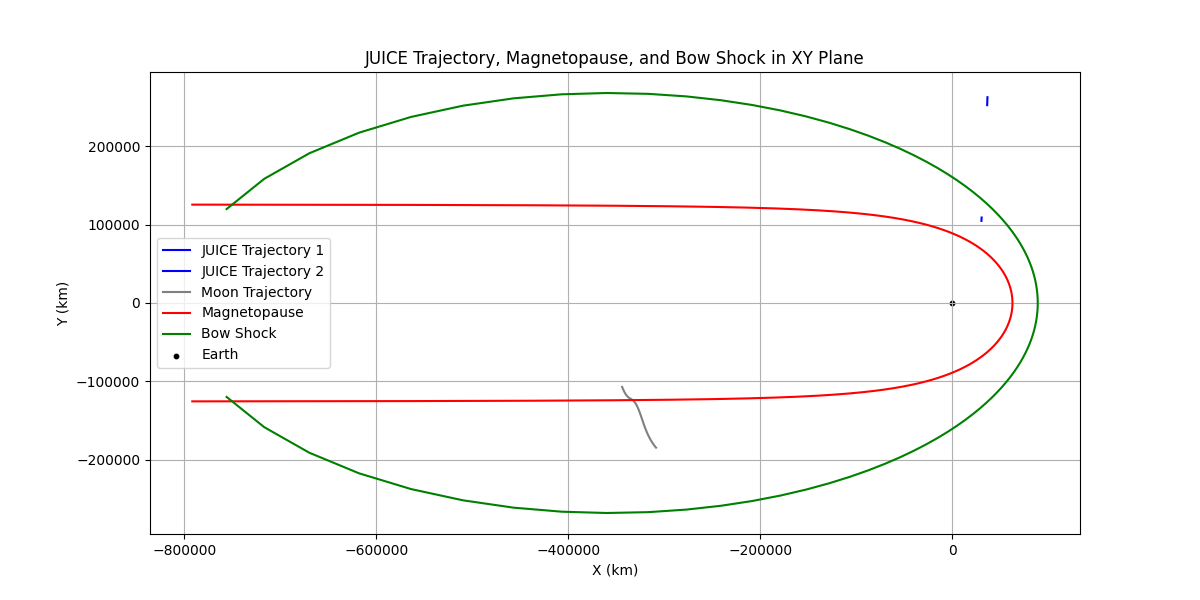

In [11]:
# Get the position of JUICE on 2024/08/21 and compare it to the positions of the magnetopause and bow shock

pressure_cdf = cdflib.CDF('../DATA/wi_k0s_swe_20240821000335_20240821235902_cdaweb.cdf')

P_sw = pressure_cdf.varget('Pressure')
P_sw[abs(P_sw) > 100] = np.nan
P_sw = np.nanmean(P_sw)
R_E = 6371  # Earth radius in km

# Load the necessary SPICE kernels
spice.furnsh("../SPICE/JUICE/kernels/mk/juice_ops.tm")
spice.furnsh("../SPICE/gsm_frame.tf")

start_date_moon = dt.datetime(2024, 8, 21, 0, 0, 0)
end_date_moon = dt.datetime(2024, 8, 22, 0, 0, 0)
et_start_moon = spice.str2et(start_date_moon.strftime("%Y-%m-%dT%H:%M:%S"))
et_end_moon = spice.str2et(end_date_moon.strftime("%Y-%m-%dT%H:%M:%S"))
time_interval_moon = np.linspace(et_start_moon, et_end_moon, num=100)
pos_moon, _ = spice.spkpos("MOON", time_interval_moon, "GSM", "NONE", "EARTH")

start_date_juice1 = dt.datetime(2024, 8, 21, 4, 25, 0)
end_date_juice1 = dt.datetime(2024, 8, 21, 4, 45, 0)
et_start_juice1 = spice.str2et(start_date_juice1.strftime("%Y-%m-%dT%H:%M:%S"))
et_end_juice1 = spice.str2et(end_date_juice1.strftime("%Y-%m-%dT%H:%M:%S"))
time_interval_juice1 = np.linspace(et_start_juice1, et_end_juice1, num=100)
pos_juice1, _ = spice.spkpos("JUICE", time_interval_juice1, "GSM", "NONE", "EARTH")

start_date_juice2 = dt.datetime(2024, 8, 21, 15, 55, 0)
end_date_juice2 = dt.datetime(2024, 8, 21, 16, 30, 0)
et_start_juice2 = spice.str2et(start_date_juice2.strftime("%Y-%m-%dT%H:%M:%S"))
et_end_juice2 = spice.str2et(end_date_juice2.strftime("%Y-%m-%dT%H:%M:%S"))
time_interval_juice2 = np.linspace(et_start_juice2, et_end_juice2, num=100)
pos_juice2, _ = spice.spkpos("JUICE", time_interval_juice2, "GSM", "NONE", "EARTH")

theta = np.linspace(-19*np.pi/20, 19*np.pi/20, 100)

# Calculate the magnetopause and bow shock positions
r_mp = magnetopause(P_sw, theta)
x_mp = R_E * r_mp * np.cos(theta)
y_mp = R_E * r_mp * np.sin(theta)

# Calculate bow shock
r_bs = bow_shock(P_sw, theta)
x_bs = R_E * r_bs * np.cos(theta)
y_bs = R_E * r_bs * np.sin(theta)

# Plot the JUICE trajectory in the XY plane as well as the magnetopause and bow shock
plt.figure(figsize=(12, 6))
plt.plot(pos_juice1[:, 0], pos_juice1[:, 1], label='JUICE Trajectory 1', color='blue')
plt.plot(pos_juice2[:, 0], pos_juice2[:, 1], label='JUICE Trajectory 2', color='blue')	
plt.plot(pos_moon[:, 0], pos_moon[:, 1], label='Moon Trajectory', color='gray')
plt.plot(x_mp, y_mp, label='Magnetopause', color='red')
plt.plot(x_bs, y_bs, label='Bow Shock', color='green')
plt.scatter(0, 0, color='black', label='Earth', s=10)  # Earth at the origin
plt.title(f'JUICE Trajectory, Magnetopause, and Bow Shock in XY Plane')
plt.xlabel('X (km)')
plt.ylabel('Y (km)')
plt.legend()
plt.grid()
plt.show()

# Unload SPICE kernels
spice.unload("../SPICE/JUICE/kernels/mk/juice_ops.tm")
spice.unload("../SPICE/GSM.tf")

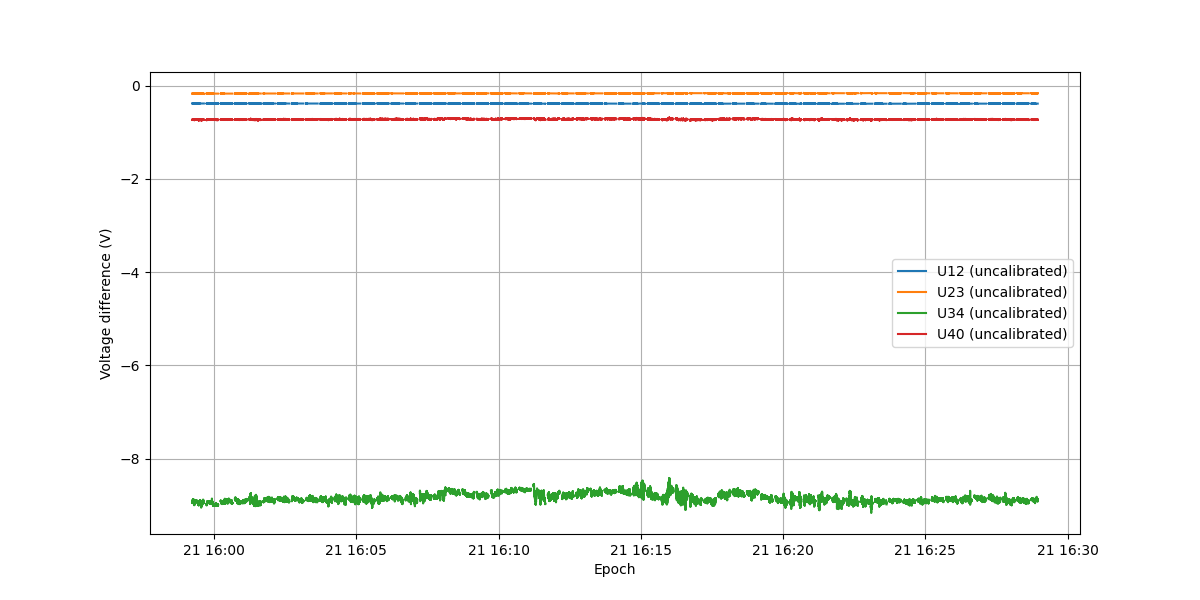

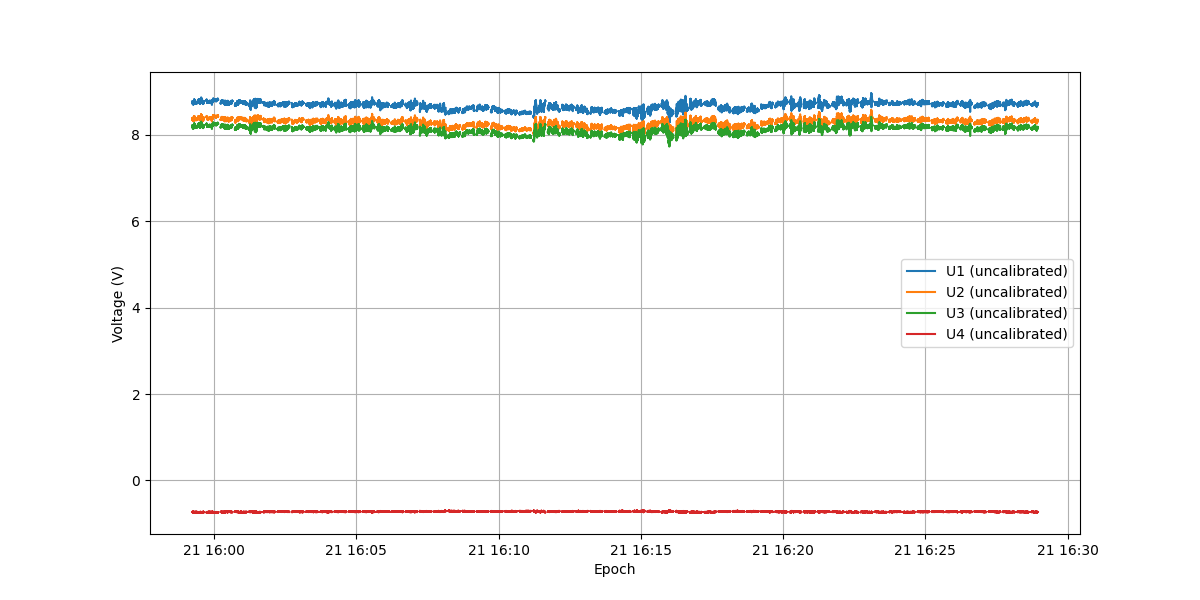

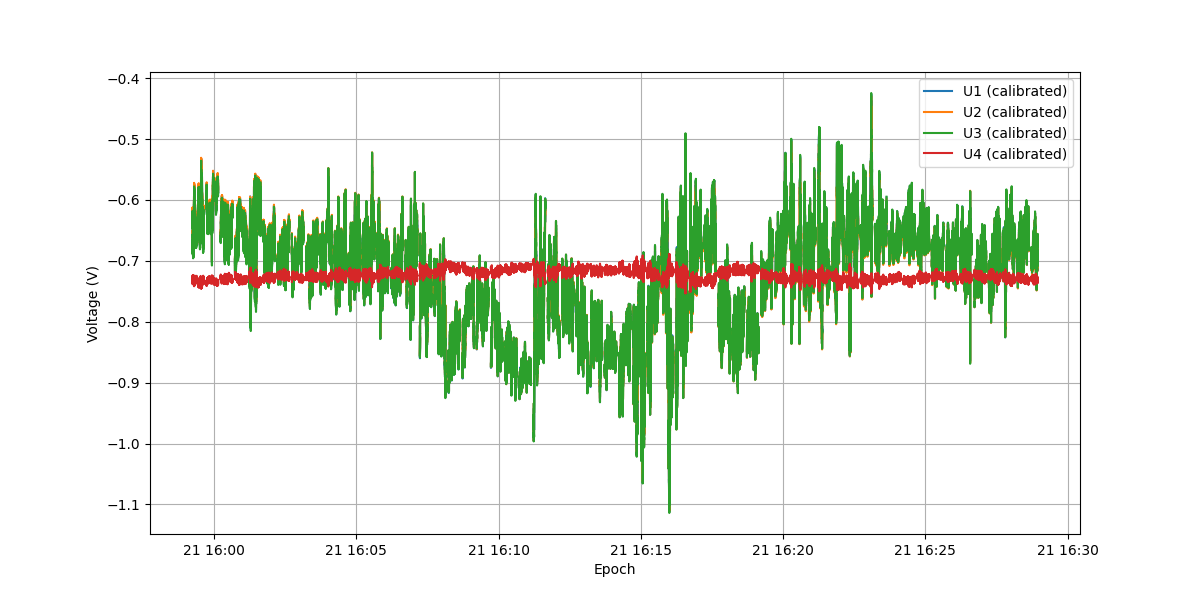

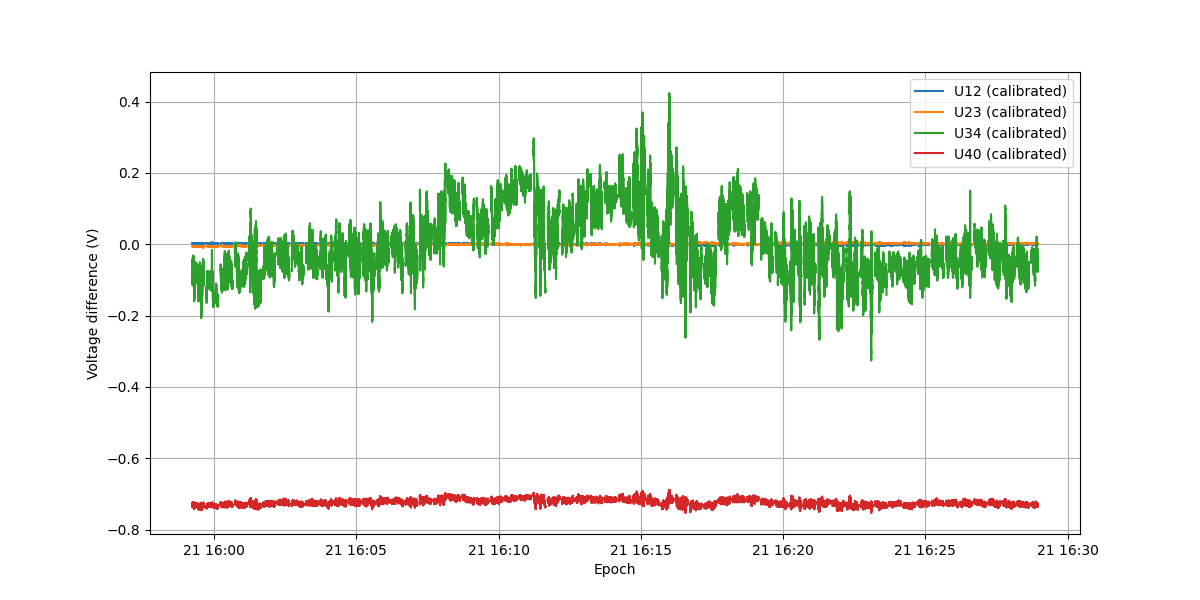

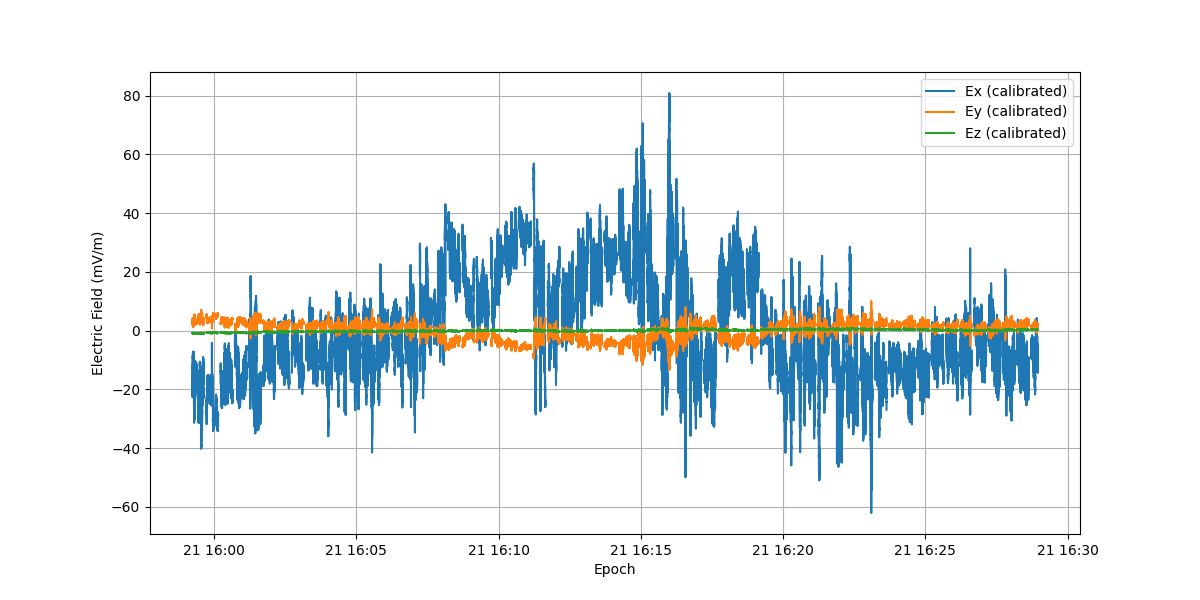

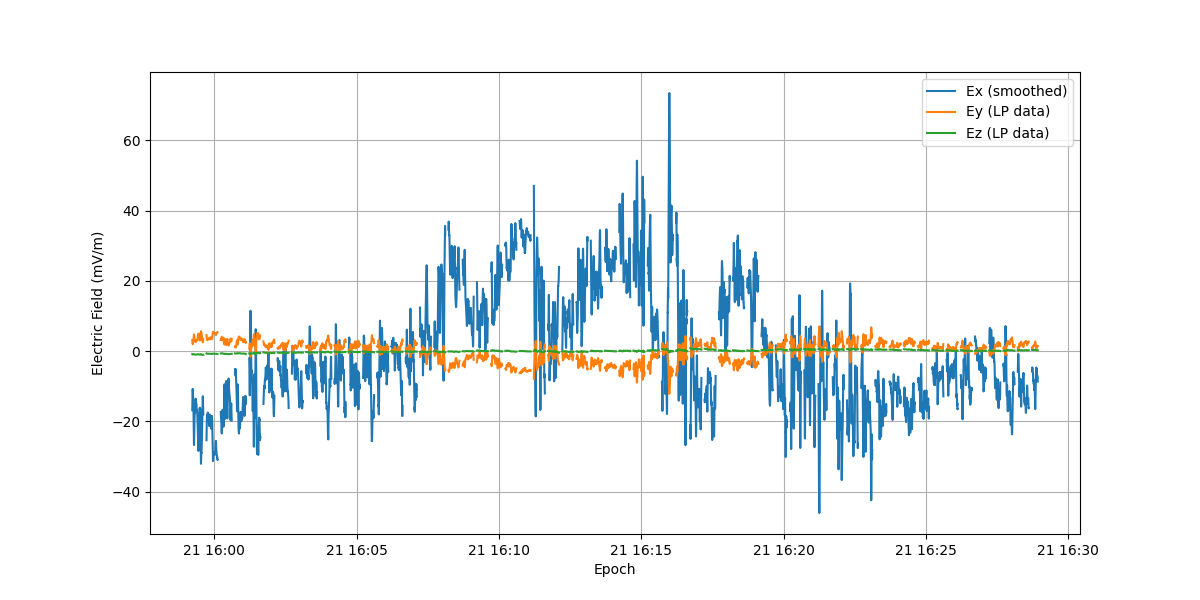

In [23]:
# Get E-f data from 2024/08/21

avg_value_correction = True
# Start and end dates for filtering
start_date = dt.datetime(2024, 8, 21, 15, 55, 0)
end_date = dt.datetime(2024, 8, 21, 16, 30, 0)

lp_cdf1 = cdflib.CDF('../DATA/JUICE_L1a_RPWI-LP-SID1_RICH_DE763_SNAP_20240821T043653_V03.cdf')
lp_cdf2 = cdflib.CDF('../DATA/JUICE_L1a_RPWI-LP-SID1_RICH_DE763_SNAP_20240821T161043_V03.cdf')

mux = lp_cdf1.varget('ADC_MUX')
diff_mode = lp_cdf1.varget('RX_AC_DC_DIFF_MODE')
labels = lp_cdf1.varget('STREAM_LABELS')

lp_epoch1 = lp_cdf1.varget('Epoch')
lp_epoch1 = cdflib.cdfepoch.to_datetime(lp_epoch1)
lp_epoch1 = np.array(lp_epoch1, dtype='datetime64[ms]').astype('O')
U12_1 = lp_cdf1.varget('LP_DATA_ENG')[:, 0]
U23_1 = lp_cdf1.varget('LP_DATA_ENG')[:, 1]
U34_1 = lp_cdf1.varget('LP_DATA_ENG')[:, 2]
U40_1 = lp_cdf1.varget('LP_DATA_ENG')[:, 3]

lp_epoch2 = lp_cdf2.varget('Epoch')
lp_epoch2 = cdflib.cdfepoch.to_datetime(lp_epoch2)
lp_epoch2 = np.array(lp_epoch2, dtype='datetime64[ms]').astype('O')
U12_2 = lp_cdf2.varget('LP_DATA_ENG')[:, 0]
U23_2 = lp_cdf2.varget('LP_DATA_ENG')[:, 1]
U34_2 = lp_cdf2.varget('LP_DATA_ENG')[:, 2]
U40_2 = lp_cdf2.varget('LP_DATA_ENG')[:, 3]

# Concatenate the data from both CDF files
lp_epoch = np.concatenate((lp_epoch1, lp_epoch2))
U12 = np.concatenate((U12_1, U12_2))
U23 = np.concatenate((U23_1, U23_2))
U34 = np.concatenate((U34_1, U34_2))
U40 = np.concatenate((U40_1, U40_2))

# Filter the TM lists and epoch list
filtered_indices = [i for i, t in enumerate(lp_epoch) if start_date <= t <= end_date]
lp_epoch = lp_epoch[filtered_indices]
U12 = U12[filtered_indices]
U23 = U23[filtered_indices]
U34 = U34[filtered_indices]
U40 = U40[filtered_indices]

U12 = filter_out_start_config_noise(U12, lp_epoch)
U23 = filter_out_start_config_noise(U23, lp_epoch)
U34 = filter_out_start_config_noise(U34, lp_epoch)
U40 = filter_out_start_config_noise(U40, lp_epoch)

plt.figure(figsize=(12, 6)) 
plt.plot(lp_epoch, U12, label='U12 (uncalibrated)')
plt.plot(lp_epoch, U23, label='U23 (uncalibrated)')
plt.plot(lp_epoch, U34, label='U34 (uncalibrated)')
plt.plot(lp_epoch, U40, label='U40 (uncalibrated)')
plt.xlabel('Epoch')
plt.ylabel('Voltage difference (V)')
plt.legend()
plt.grid()
plt.show()

U1, U2, U3, U4 = multiply_lists_by_44matrix(U12, U23, U34, U40, diff2volt)

plt.figure(figsize=(12, 6))
plt.plot(lp_epoch, U1, label='U1 (uncalibrated)')
plt.plot(lp_epoch, U2, label='U2 (uncalibrated)')
plt.plot(lp_epoch, U3, label='U3 (uncalibrated)')
plt.plot(lp_epoch, U4, label='U4 (uncalibrated)')
plt.xlabel('Epoch')
plt.ylabel('Voltage (V)')
plt.legend()
plt.grid()
plt.show()

if avg_value_correction:
    mean_diff_U1 = np.nanmean(np.array(U4) - np.array(U1))
    mean_diff_U2 = np.nanmean(np.array(U4) - np.array(U2))
    mean_diff_U3 = np.nanmean(np.array(U4) - np.array(U3))

    U1 = np.array([float(u) + float(mean_diff_U1) for u in U1])
    U2 = np.array([float(u) + float(mean_diff_U2) for u in U2])
    U3 = np.array([float(u) + float(mean_diff_U3) for u in U3])

plt.figure(figsize=(12, 6))
plt.plot(lp_epoch, U1, label='U1 (calibrated)')
plt.plot(lp_epoch, U2, label='U2 (calibrated)')
plt.plot(lp_epoch, U3, label='U3 (calibrated)')
plt.plot(lp_epoch, U4, label='U4 (calibrated)')
plt.xlabel('Epoch')
plt.ylabel('Voltage (V)')
plt.legend()
plt.grid()
plt.show()

U12, U23, U34, U40 = multiply_lists_by_44matrix(U1, U2, U3, U4, volt2diff)

plt.figure(figsize=(12, 6))
plt.plot(lp_epoch, U12, label='U12 (calibrated)')
plt.plot(lp_epoch, U23, label='U23 (calibrated)')
plt.plot(lp_epoch, U34, label='U34 (calibrated)')
plt.plot(lp_epoch, U40, label='U40 (calibrated)')
plt.xlabel('Epoch')
plt.ylabel('Voltage difference (V)')
plt.legend()
plt.grid()
plt.show()

Ex, Ey, Ez = multiply_lists_by_33matrix(U12, U23, U34, volt2E)

plt.figure(figsize=(12, 6))
plt.plot(lp_epoch, Ex*1e3, label='Ex (calibrated)')
plt.plot(lp_epoch, Ey*1e3, label='Ey (calibrated)')
plt.plot(lp_epoch, Ez*1e3, label='Ez (calibrated)')
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.legend()
plt.grid()
plt.show()

nb_points_avg = 1000

# Smooth E-field data using a 10-point rolling average
Ex_smooth = np.convolve(Ex, np.ones(nb_points_avg)/nb_points_avg, mode='valid')
Ey_smooth = np.convolve(Ey, np.ones(nb_points_avg)/nb_points_avg, mode='valid')
Ez_smooth = np.convolve(Ez, np.ones(nb_points_avg)/nb_points_avg, mode='valid')

# Adjust the epoch to match the smoothed data length
lp_epoch_smooth = lp_epoch[:len(Ex_smooth)]

plt.figure(figsize=(12, 6))
plt.plot(lp_epoch_smooth, Ex_smooth*1e3, label='Ex (smoothed)')
plt.plot(lp_epoch_smooth, Ey_smooth*1e3, label='Ey (LP data)')
plt.plot(lp_epoch_smooth, Ez_smooth*1e3, label='Ez (LP data)')
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.legend()
plt.grid()
plt.show()

C:\Users\lesco\AppData\Local\Temp\ipykernel_1860\3088924231.py:47: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


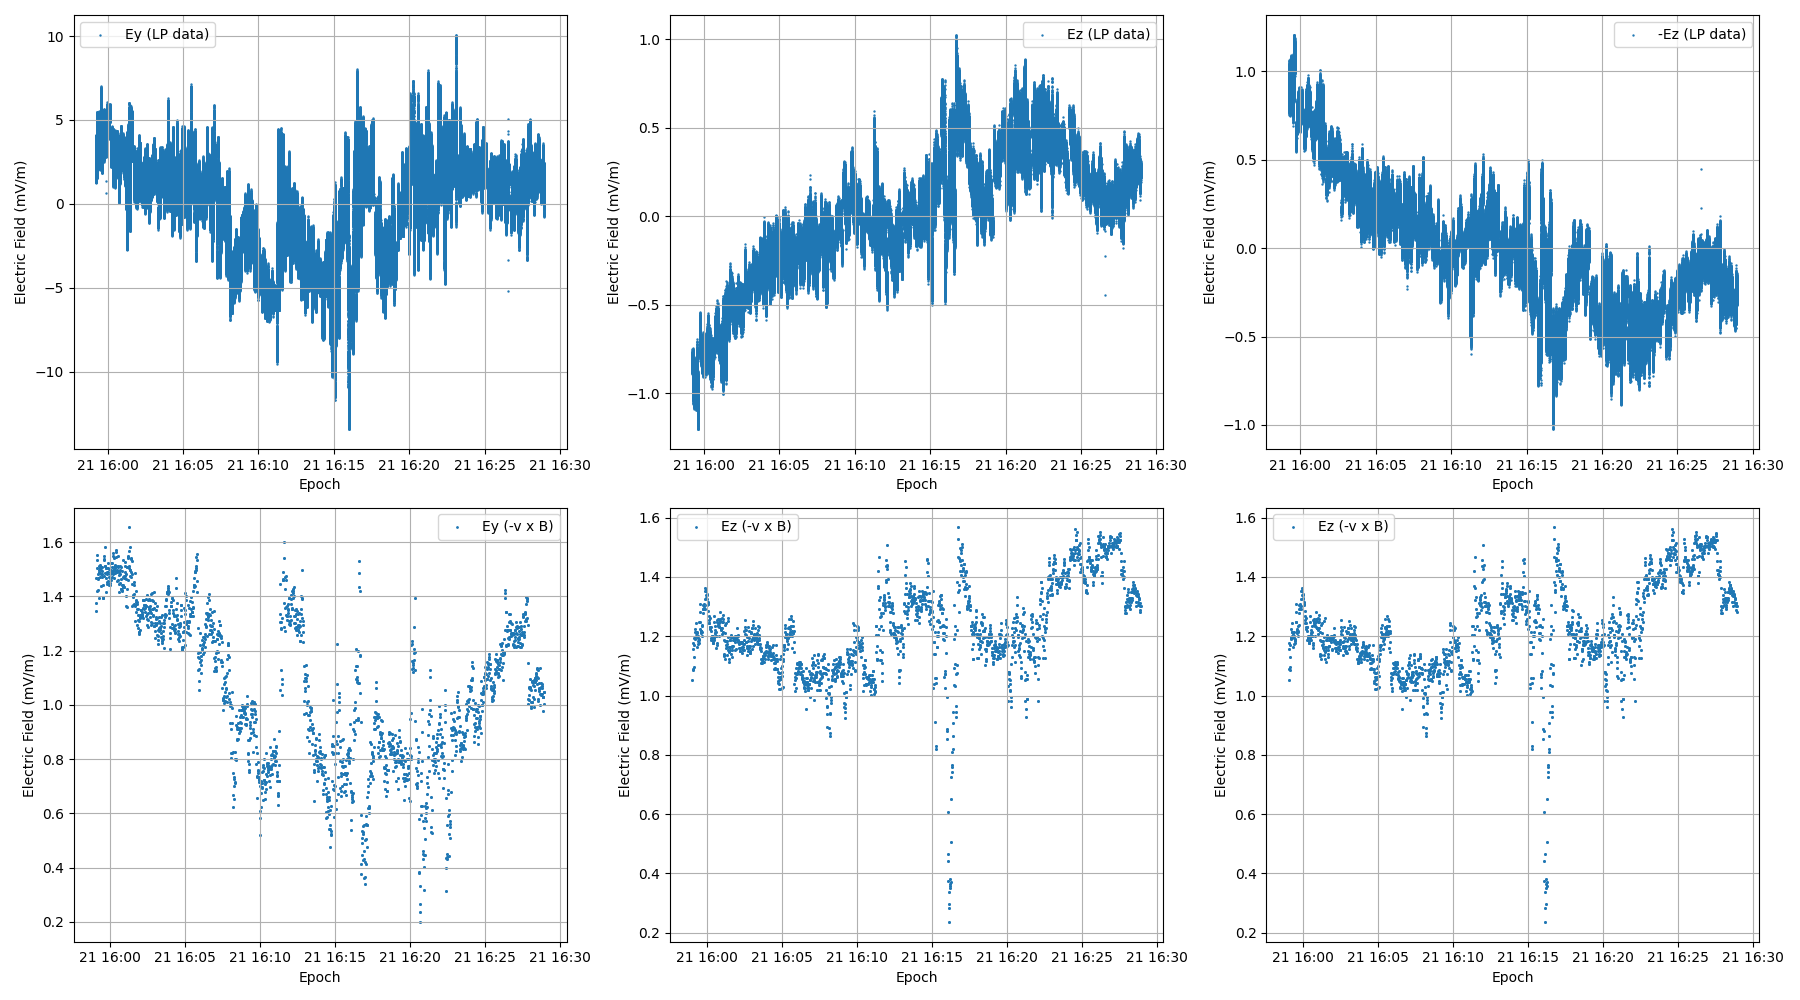

In [9]:
# Plotting LP data next to - v cross B data for 2024/08/21

plt.figure(figsize=(18, 10))

plt.subplot(2, 3, 1)
plt.scatter(lp_epoch, Ey*1e3, label='Ey (LP data)', s=0.5)
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.legend()
plt.grid()

plt.subplot(2, 3, 2)
plt.scatter(lp_epoch, Ez*1e3, label='Ez (LP data)', s=0.5)
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.legend()
plt.grid()

plt.subplot(2, 3, 3)
plt.scatter(lp_epoch, -Ez*1e3, label='-Ez (LP data)', s=0.5)
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.legend()
plt.grid()

plt.subplot(2, 3, 4)
plt.scatter(jmag_epoch2, EyvCB*1e3, label='Ey (-v x B)', s=1)
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.legend()
plt.grid()

plt.subplot(2, 3, 5)
plt.scatter(jmag_epoch2, EzvCB*1e3, label='Ez (-v x B)', s=1)
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.legend()
plt.grid()

plt.subplot(2, 3, 6)
plt.scatter(jmag_epoch2, EzvCB*1e3, label='Ez (-v x B)', s=1)
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

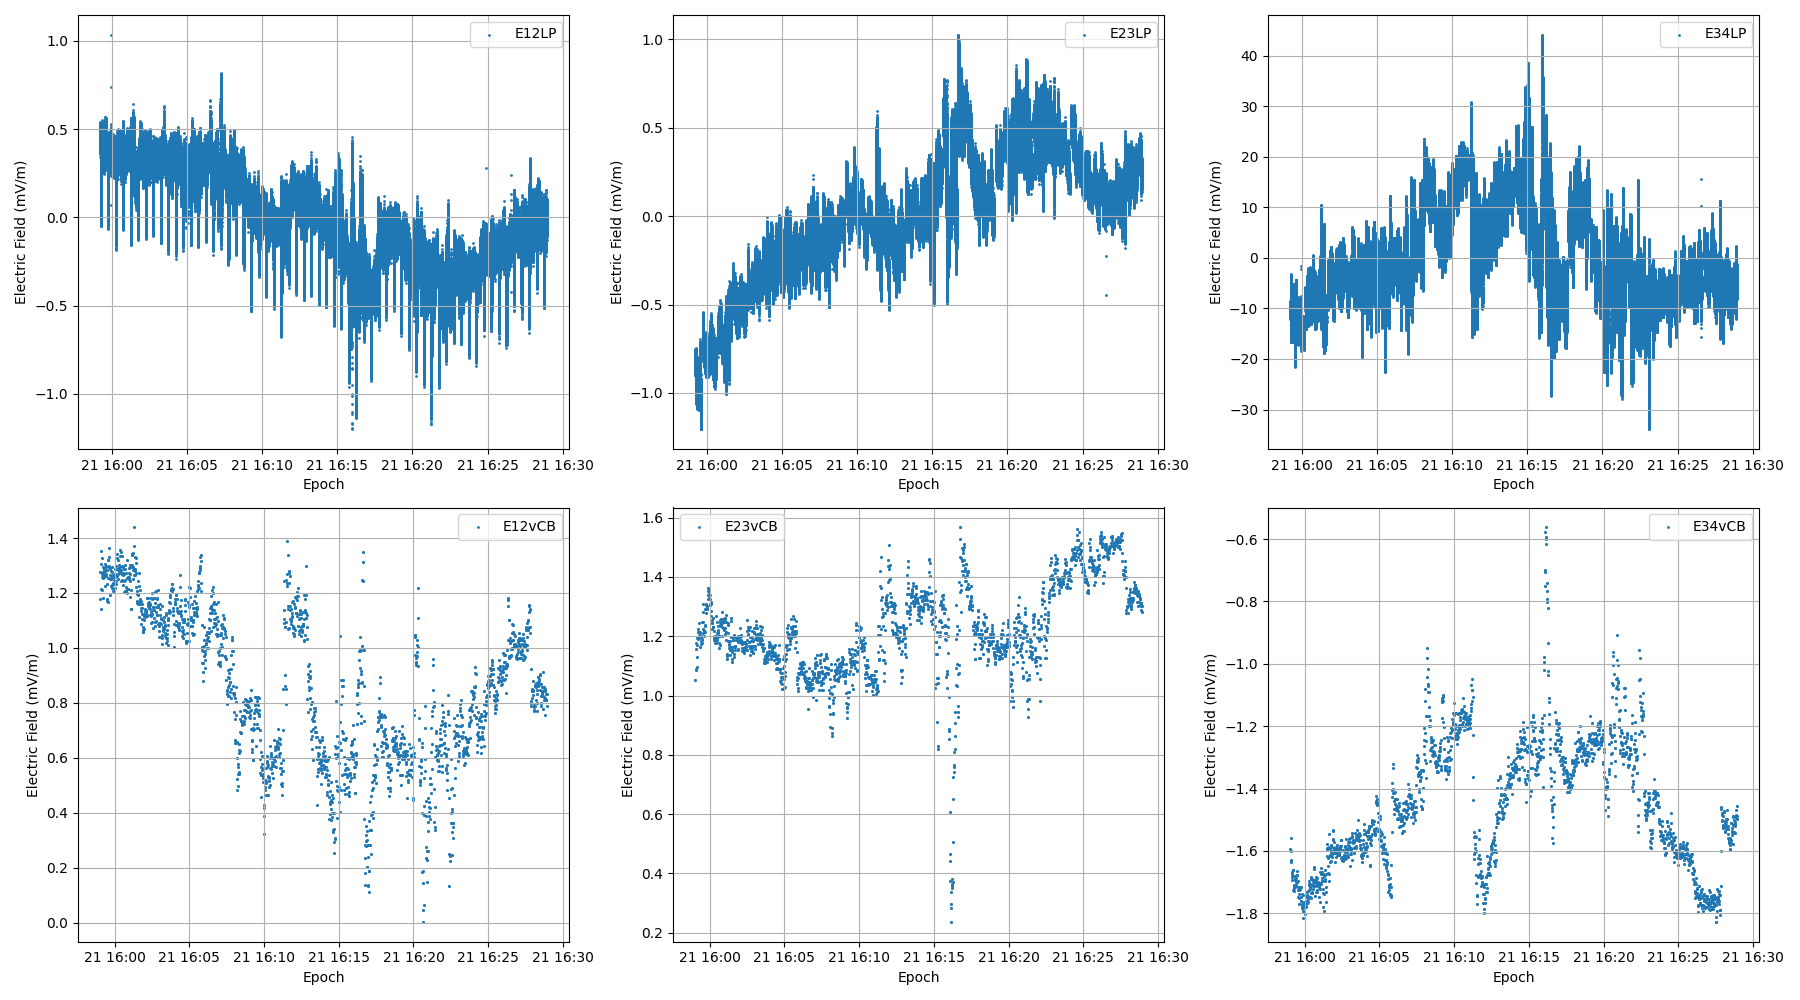

In [10]:
# Trying to look at data in the LP probe frame for 21/08/2024

E12vCB, E23vCB, E34vCB = multiply_lists_by_33matrix(ExvCB, EyvCB, EzvCB, E2volt)
E12vCB = E12vCB / probe_dist[0]
E23vCB = E23vCB / probe_dist[1]
E34vCB = E34vCB / probe_dist[2]

E12LP, E23LP, E34LP = multiply_lists_by_33matrix(Ex, Ey, Ez, E2volt)
E12LP = E12LP / probe_dist[0]
E23LP = E23LP / probe_dist[1]
E34LP = E34LP / probe_dist[2]

plt.figure(figsize=(18, 10))

plt.subplot(2, 3, 1)
plt.scatter(lp_epoch, E12LP*1e3, label='E12LP', s=1)
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.legend()
plt.grid()

plt.subplot(2, 3, 2)
plt.scatter(lp_epoch, E23LP*1e3, label='E23LP', s=1)
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.legend()
plt.grid()

plt.subplot(2, 3, 3)
plt.scatter(lp_epoch, E34LP*1e3, label='E34LP', s=1)
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.legend()
plt.grid()

plt.subplot(2, 3, 4)
plt.scatter(jmag_epoch2, E12vCB*1e3, label='E12vCB', s=1)
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.legend()
plt.grid()

plt.subplot(2, 3, 5)
plt.scatter(jmag_epoch2, E23vCB*1e3, label='E23vCB', s=1)
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.legend()
plt.grid()

plt.subplot(2, 3, 6)
plt.scatter(jmag_epoch2, E34vCB*1e3, label='E34vCB', s=1)
plt.xlabel('Epoch')
plt.ylabel('Electric Field (mV/m)')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

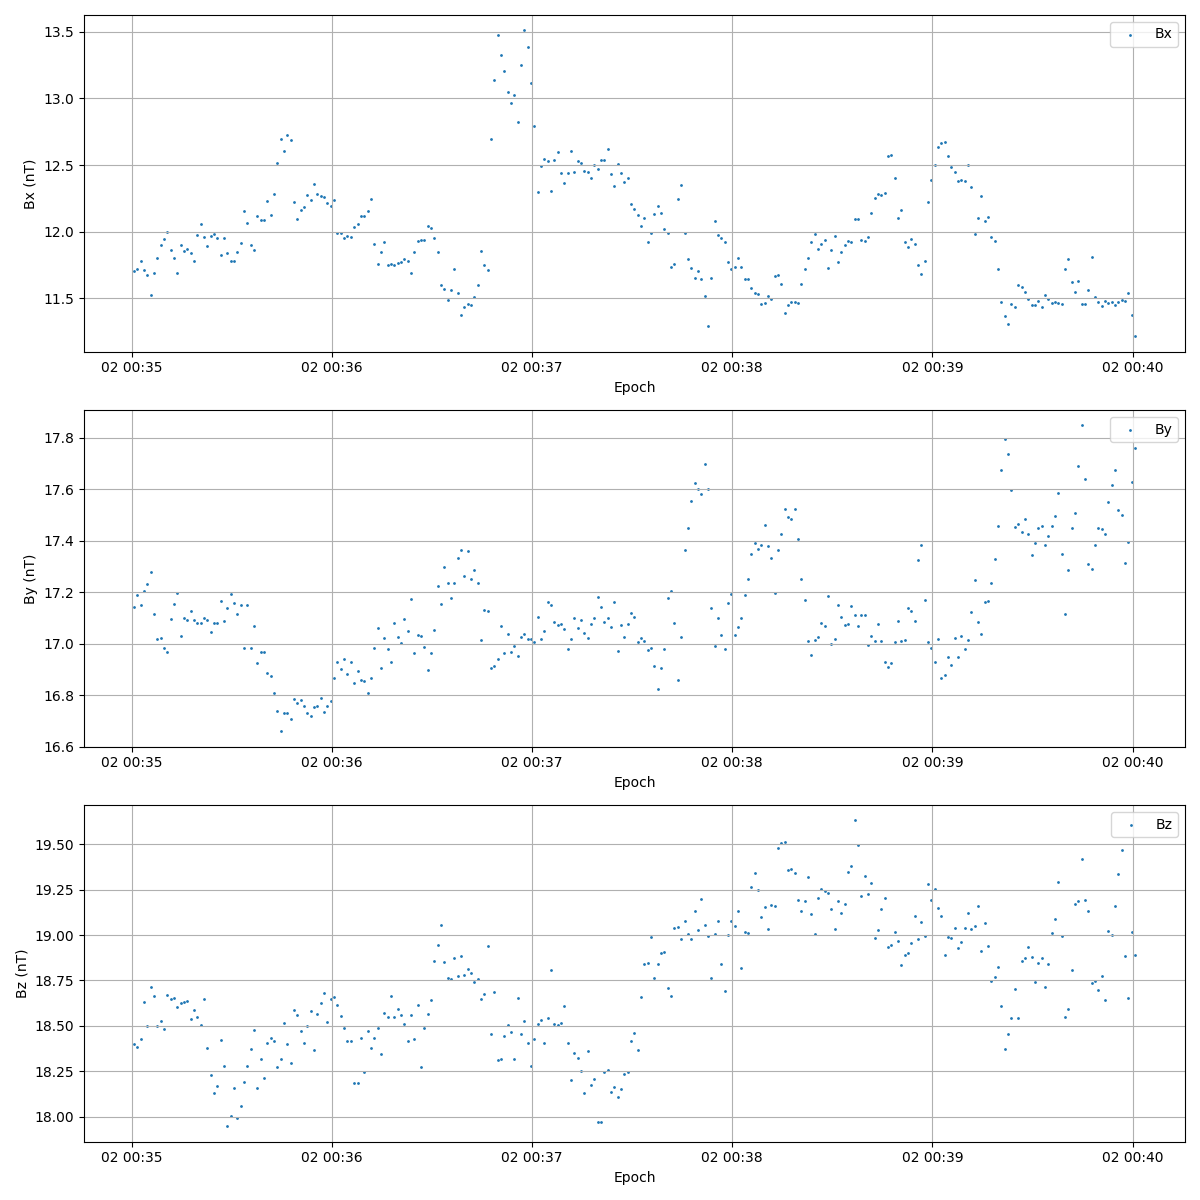

In [2]:
# Reading jmag_echoed data from 02/07/2024

jmag_cdf = cdflib.CDF('../DATA/jmag_echoed/2024/07/02/JUICE_LU_RPWI-PPTD-LWYRPW79700_20240702T003500_V02.cdf')
NMD = jmag_cdf.varget('NMD')
epoch = jmag_cdf.varget('Epoch')
epoch = cdflib.cdfepoch.to_datetime(epoch)
epoch = np.array(epoch, dtype='datetime64[ms]').astype('O')

JMAG_Bx = extract_double_from_columns(NMD, 9, 17)
JMAG_By = extract_double_from_columns(NMD, 17, 25)
JMAG_Bz = extract_double_from_columns(NMD, 25, 33)

JMAG_Bx = np.where(np.abs(JMAG_Bx) < 1e-9, np.nan, JMAG_Bx)
JMAG_By = np.where(np.abs(JMAG_By) < 1e-9, np.nan, JMAG_By)
JMAG_Bz = np.where(np.abs(JMAG_Bz) < 1e-9, np.nan, JMAG_Bz)

plt.figure(figsize=(12, 12))

plt.subplot(3, 1, 1)
plt.scatter(epoch, JMAG_Bx, label='Bx', s = 1)
plt.xlabel('Epoch')
plt.ylabel('Bx (nT)')
plt.grid()
plt.legend()

plt.subplot(3, 1, 2)
plt.scatter(epoch, JMAG_By, label='By', s = 1)
plt.xlabel('Epoch')
plt.ylabel('By (nT)')
plt.grid()
plt.legend()

plt.subplot(3, 1, 3)
plt.scatter(epoch, JMAG_Bz, label='Bz', s = 1)
plt.xlabel('Epoch')
plt.ylabel('Bz (nT)')
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()